# Muestra de artículos de prensa (2019–2026) — EDA, embeddings y clustering

Pipeline completo sobre artículos de **Diario Expreso**, **El Universo** y
**Primicias**, organizado en cinco secciones:

1. **EDA** sobre el texto crudo.
2. **Data Wrangling**: normalización, deduplicación, sección canónica y filtro de longitud.
3. **Embeddings**: cinco modelos modernos y una ablación controlada de instrucción.
4. **Clustering**: HDBSCAN con y sin UMAP, jerarquía, membresía probabilística y métricas.
5. **AE / VAE**: reducción neural exploratoria, reutilizando el mismo pipeline.

Comparación principal:

| Modelo | Contexto | Tratamiento |
|---|---:|---|
| `BAAI/bge-m3` | 8192 | dense embedding nativo |
| `jinaai/jina-embeddings-v3` | 8192 | adaptador `task="separation"` |
| `intfloat/multilingual-e5-large` | 512 | prefijo `query:` + chunking |
| `Qwen/Qwen3-Embedding-0.6B` | 32768 | instrucción temática neutral |
| `jinaai/jina-embeddings-v2-base-es` | 8192 | embedding bilingüe español–inglés |

`Qwen3-no-instruct` se conserva como ablación separada y no participa como sexto
candidato en la selección del ganador. Todos los modelos producen un vector L2 por
artículo; si el texto excede el contexto, los chunks se agregan ponderando únicamente
la cobertura nueva para no duplicar el overlap.

In [24]:
%cd /home/pherrera/projects/clustering_n_rag_u_index/notebooks
%pwd

/home/pherrera/projects/clustering_n_rag_u_index/notebooks


'/home/pherrera/projects/clustering_n_rag_u_index/notebooks'

In [25]:
import sys
from pathlib import Path

# Ancla la raíz del repo esté donde esté el kernel (local o Colab)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [26]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Raíz del repo en el path (para importar src.llm_clients, como en scripts/check_vllm.py)
sys.path.insert(0, str(Path.cwd().parent))

# Paleta categórica fija por periódico (orden alfabético estable)
PALETA = ["#0057ff", "#00d84a", "#ff2bd6"]  # azul intenso, verde intenso, magenta intenso
COLOR_FLAG = {0: "#8f8a7a", 1: "#ff1a1a"}   # gris más profundo / rojo intenso

sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42

---
# 1. EDA

Análisis exploratorio **sin modificar los datos**: todo lo que sigue se mide sobre el texto
tal como llega del CSV. Las correcciones que este análisis justifica se aplican después, en
la sección 2 (Data Wrangling).


## Carga y tipos


In [27]:
data = pd.read_csv(RAIZ / "data" / "raw" / "stratified_grid_2019_2026.csv")
data

,id_articulo,id_pressreader,titulo,texto,seccion,seccion_canonica,fecha,id_periodico,nombre_periodico,anio,incertidumbre,economic_uncertainty,political_uncertainty,icor_index,icor_v2_index,icor_v3_1_index
0,109787,NaN,No Trabajan Y Quieren Sueldo,"Gabriela Rivadeneira, Soledad Buendía, Carlos ...",Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,1,1
1,109788,NaN,El 11 De Noviembre Estaría Listo El Informe De...,El destino de la reforma tributaria del Ejecut...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
2,109789,NaN,Las Enmiendas Constitucionales Aterrizan En Un...,Otra comisión en la Asamblea Nacional. El Cons...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
3,109790,NaN,El Ejecutivo Defiende El Veto Al Código Orgáni...,El Gobierno retoma la estrategia de explicar s...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
4,109791,NaN,Ecuador Quiere Enganchar A Los Turistas Paragu...,Representantes de empresas turísticas del Ecua...,Actualidad,Actualidad,2019-10-23,2,Diario Expreso,2019,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28772,302988,NaN,Cinco Frutas Exóticas Y Milagrosas De La Amazo...,¿Sabía que la chonta puede ayudar a controlar ...,Gastronomía,Vida y Estilo,2025-01-29,4,Primicias,2025,0,0,0,0,0,0
28773,309044,NaN,"El Ají, Parte Indiscutible De La Gastronomía E...",En enero se celebra el Día Internacional de la...,Gastronomía,Vida y Estilo,2025-01-31,4,Primicias,2025,0,0,0,0,0,0
28774,311137,NaN,"Roberto Ayala, Ganador De Masterchef Ecuador, ...","Conocido como 'El hombre Ayala', Roberto ganó ...",Gastronomía,Vida y Estilo,2025-02-03,4,Primicias,2025,0,0,0,0,0,0
28775,324194,NaN,Ecuador Ganó El Premio A La Mejor Cocina Latin...,"El reconocimiento fue entregado por H10, una d...",Gastronomía,Vida y Estilo,2025-02-08,4,Primicias,2025,0,0,0,0,0,0


In [28]:
data.columns.to_list()

['id_articulo',
 'id_pressreader',
 'titulo',
 'texto',
 'seccion',
 'seccion_canonica',
 'fecha',
 'id_periodico',
 'nombre_periodico',
 'anio',
 'incertidumbre',
 'economic_uncertainty',
 'political_uncertainty',
 'icor_index',
 'icor_v2_index',
 'icor_v3_1_index']

In [29]:
data.drop(columns=["id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data.rename({"incertidumbre": "u_index",
            "economic_uncertainty": "economic_u_index",
            "political_uncertainty": "political_u_index",},
            axis=1, inplace=True)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28777 entries, 0 to 28776
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_articulo        28777 non-null  int64 
 1   titulo             28777 non-null  object
 2   texto              28777 non-null  object
 3   seccion            28776 non-null  object
 4   seccion_canonica   28777 non-null  object
 5   fecha              28777 non-null  object
 6   nombre_periodico   28777 non-null  object
 7   anio               28777 non-null  int64 
 8   u_index            28777 non-null  int64 
 9   economic_u_index   28777 non-null  int64 
 10  political_u_index  28777 non-null  int64 
 11  icor_v3_1_index    28777 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 2.6+ MB


In [31]:
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = pd.to_datetime(data["anio"], format="%Y").dt.year
data["fecha"], data["anio"]

(0       2019-10-23
 1       2019-10-23
 2       2019-10-23
 3       2019-10-23
 4       2019-10-23
            ...    
 28772   2025-01-29
 28773   2025-01-31
 28774   2025-02-03
 28775   2025-02-08
 28776   2025-07-16
 Name: fecha, Length: 28777, dtype: datetime64[ns],
 0        2019
 1        2019
 2        2019
 3        2019
 4        2019
          ... 
 28772    2025
 28773    2025
 28774    2025
 28775    2025
 28776    2025
 Name: anio, Length: 28777, dtype: int32)

## Calidad de datos

Nulos, duplicados y consistencia básica antes de cualquier análisis.

In [32]:
print("Nulos por columna:")
print(data.isna().sum())
print(f"\nDuplicados por id_articulo: {data['id_articulo'].duplicated().sum()}")
print(f"Duplicados por (titulo, texto): {data.duplicated(subset=['titulo', 'texto']).sum()}")
print(f"Textos vacíos: {(data['texto'].str.strip().str.len() == 0).sum()}")
print(f"Rango de fechas: {data['fecha'].min().date()} → {data['fecha'].max().date()}")

Nulos por columna:
id_articulo          0
titulo               0
texto                0
seccion              1
seccion_canonica     0
fecha                0
nombre_periodico     0
anio                 0
u_index              0
economic_u_index     0
political_u_index    0
icor_v3_1_index      0
dtype: int64

Duplicados por id_articulo: 0
Duplicados por (titulo, texto): 0
Textos vacíos: 0
Rango de fechas: 2019-03-30 → 2026-07-09


## Análisis de calidad del texto

In [33]:
import re
import unicodedata
import collections
import pandas as pd


def diagnosticar_textos(df, col="texto", n_ejemplos=3, ancho=160):
    """Audita la columna de texto: prevalencia de artefactos conocidos + descubrimiento
    de codepoints no-ASCII no esperados. Solo reporta, no modifica nada."""
    t = df[col].fillna("").astype(str)
    N = len(t)

    # --- Patrones conocidos: (nombre, regex, es_grave) ---
    PATRONES = [
        ("Palabras pegadas (min.Mayus)", r"[a-záéíóúñ][.,;:!?][A-ZÁÉÍÓÚÑ]", True),
        ("Soft hyphen \\xad (parte palabras)", r"\xad", True),
        ("Pictogramas de recuadro", r"[■⬛◼◗❚❑►▶●◉‣]", True),
        ("Crucigrama (HORIZONTALES/VERTICALES)", r"HORIZONTALES|VERTICALES", True),
        ("Comillas tipográficas", r"[“”‘’«»]", False),
        ("Guiones tipográficos", r"[–—−]", False),
        ("Código sección final (I)/(O)/(E)", r"\(\s*[IOEFR]\s*\)\s*$", False),
        ("URLs", r"https?://|www\.", False),
        ("Emails", r"\b[\w.-]+@[\w.-]+\.\w+", False),
        ("Acentos combinantes (no-NFC)", r"[\u0300-\u036f]", False),
        ("Viñetas numeradas ≥6 (listas)", None, False),   # caso especial: conteo
        ("Runs de -- __ ..", r"[-_.]{4,}", False),
        ("Marker recuadro AL INICIO", r"^\s*[■⬛◼◗❚❑►▶●]", True),
        ("Dígito pegado a letra (12años)", r"\d[a-záéíóúñ]{3,}|[a-záéíóúñ]{4,}\d{4}", False),
    ]

    print(f"{'='*70}\nDIAGNÓSTICO — columna '{col}', {N:,} textos\n{'='*70}")
    print(f"{'PATRÓN':<40}{'DOCS':>8}{'%':>8}  GRAVE")
    print("-" * 70)
    hallazgos = {}
    for nombre, patron, grave in PATRONES:
        if patron is None:  # viñetas numeradas: umbral por conteo
            mask = t.str.count(r"\b\d+\.\s") >= 6
        else:
            mask = t.str.contains(patron, regex=True)
        n = int(mask.sum())
        hallazgos[nombre] = mask
        marca = "  🔴" if (grave and n) else ""
        print(f"{nombre:<40}{n:>8,}{n/N*100:>7.2f}%{marca}")

    # --- Duplicados ---
    dup_texto = int(df.duplicated(subset=[col], keep=False).sum())
    print("-" * 70)
    print(f"{'Textos duplicados exactos':<40}{dup_texto:>8,}{dup_texto/N*100:>7.2f}%")

    # --- DESCUBRIMIENTO: codepoints no-ASCII no esperados ---
    ESPERADOS = set("áéíóúñüÁÉÍÓÚÑÜ¿¡«»“”‘’–—−…■⬛◼◗❚❑►▶●")
    ESPERADOS |= set("çèãöëàäïô×øêâåºª°´²³©®™°")  # acentos/símbolos ya vistos
    cont = collections.Counter()
    for s in t:
        for ch in s:
            if ord(ch) > 127 and ch not in ESPERADOS and not unicodedata.combining(ch):
                cont[ch] += 1
    if cont:
        print(f"\n{'CODEPOINTS NO-ASCII INESPERADOS (posibles hallazgos nuevos)':^70}")
        print(f"{'CODEPOINT':<12}{'CAT':<5}{'OCURR':>8}{'DOCS':>7}  NOMBRE / ejemplo")
        print("-" * 70)
        for ch, oc in cont.most_common(25):
            docs = int(t.str.contains(re.escape(ch)).sum())
            nombre_u = unicodedata.name(ch, "?")
            print(f"U+{ord(ch):04X}{'':<6}{unicodedata.category(ch):<5}{oc:>8,}{docs:>7}  {nombre_u} {ch!r}")

    # --- Ejemplos concretos de los patrones graves ---
    print(f"\n{'='*70}\nEJEMPLOS (patrones graves)\n{'='*70}")
    for nombre, mask in hallazgos.items():
        graves = {p[0] for p in PATRONES if p[2]}
        if nombre not in graves or mask.sum() == 0:
            continue
        print(f"\n### {nombre} ({int(mask.sum()):,} docs)")
        for s in t[mask].head(n_ejemplos):
            frag = re.sub(r"\s+", " ", s).strip()
            print(f"  · {frag}")

    return hallazgos  # dict {patrón: máscara booleana} por si quieres filtrar con ellos

In [34]:
# El diagnóstico se ejecuta sobre titulo + seccion + texto: los artefactos no viven solo
# en el cuerpo (las etiquetas de sección casi duplican la cuenta de soft hyphens). El
# separador "\n" no crea falsos "palabras pegadas" en los bordes entre campos.
data["texto_diag"] = (data["titulo"].fillna("") + "\n"
                      + data["seccion"].fillna("") + "\n"
                      + data["texto"].fillna(""))
hallazgos = diagnosticar_textos(data, col="texto_diag")

DIAGNÓSTICO — columna 'texto_diag', 28,777 textos
PATRÓN                                      DOCS       %  GRAVE
----------------------------------------------------------------------
Palabras pegadas (min.Mayus)              13,611  47.30%  🔴
Soft hyphen \xad (parte palabras)          2,359   8.20%  🔴
Pictogramas de recuadro                      851   2.96%  🔴
Crucigrama (HORIZONTALES/VERTICALES)          32   0.11%  🔴
Comillas tipográficas                     12,325  42.83%
Guiones tipográficos                       1,361   4.73%
Código sección final (I)/(O)/(E)           3,293  11.44%
URLs                                         249   0.87%
Emails                                        96   0.33%
Acentos combinantes (no-NFC)                  10   0.03%
Viñetas numeradas ≥6 (listas)                215   0.75%
Runs de -- __ ..                              28   0.10%
Marker recuadro AL INICIO                    104   0.36%  🔴
Dígito pegado a letra (12años)               142   0.49%
--

### Diagnóstico de artefactos de texto (PressReader)

El texto proviene de PressReader y arrastra artefactos de maquetación que
**no son contenido** y degradan silenciosamente los embeddings (sobre todo en modelos
subword como BETO y BGE-M3, donde un carácter invisible a media palabra rompe la
tokenización). El diagnóstico se ejecuta sobre la concatenación `titulo + seccion + texto`,
para cubrir todo el material que llega al modelo (título y cuerpo se embeben juntos) más la
etiqueta de sección. Prevalencia medida sobre el corpus completo (28,777 artículos):

| Artefacto | Docs | % | Impacto |
|---|---:|---:|---|
| Palabras pegadas tras puntuación (`Lloret.En`) | 13,611 | 47.3% | Alto |
| Comillas tipográficas (`" " ' '`) | 12,325 | 42.8% | Bajo (cosmético) |
| Código de sección final `(I)`/`(O)`/`(E)` | 3,293 | 11.4% | Bajo |
| Soft hyphen `\xad` (parte palabras: `Actualidad`) | 2,359 | 8.2% | Alto |
| Guiones tipográficos (`– — −`) | 1,361 | 4.7% | Bajo |
| Pictogramas de recuadro (`■ ▶ ⬛ ◗ • ❏ ▪`) | 851 | 3.0% | Medio (ruido puro) |
| Dígito pegado a letra (`12años`) | 142 | 0.5% | Bajo |
| Crucigramas (`HORIZONTALES`/`VERTICALES`) | 32 | 0.1% | Alto (contenido no temático) |
| Private Use Area `\uF07D`, non-breaking hyphen `\u2011`, variation selectors `\uFE0F` | <10 c/u | — | Bajo |

**Observaciones clave:**

- **Los artefactos no viven solo en `texto`.** Al añadir `titulo` y `seccion` al diagnóstico,
  el soft hyphen casi se duplica (1,345 → 2,359 docs): las **etiquetas de sección vienen
  partidas** (`Actualidad`, `Diversión`). Esto no es cosmético: `seccion` alimenta la
  canonicalización de secciones, y `Actualidad` ≠ `Actualidad` haría
  cuente como dos. Por eso `seccion` también necesita al menos la limpieza de invisibles.
- El artefacto dominante son las **palabras pegadas** (47%): PressReader pierde el espacio tras
  el punto final de oración. Es corregible **solo** cuando queda punt
  palabras; la fracción pegada sin puntuación (`deImpuesto`, `mientraspermanecía`) es
  **irrecuperable** sin un segmentador y se delega en la tokenización subword del modelo.
- El **soft hyphen** (`\xad`, 95k ocurrencias) es el más traicionero:
  el tokenizer lo procesa y parte `primer` en subtokens espurios.
- Se detectó un carácter **Private Use Area** (`U+F07D`, categoría `C
  de la fuente de PressReader, sin significado Unicode → basura que se elimina.
- Los caracteres extranjeros detectados (`č ć š ž Ö Ç à ½ ₂`) son **contenido legítimo**
  (nombres eslavos/germánicos, fracciones, fórmulas) y **no** se tocan. No hay duplicados de
  texto (0 exactos).

## Longitud de los textos

In [35]:
# Longitudes sobre el texto CRUDO (aún sin normalizar). La sección 2 vuelve a medirlas
# tras la limpieza, y la comparación antes/después es en sí un resultado.
data["n_caracteres"] = data["texto"].str.len()
data["n_palabras"] = data["texto"].str.split().str.len()
data[["texto", "n_caracteres", "n_palabras"]].head(3)

,texto,n_caracteres,n_palabras
0,"Gabriela Rivadeneira, Soledad Buendía, Carlos ...",4654,740
1,El destino de la reforma tributaria del Ejecut...,1539,250
2,Otra comisión en la Asamblea Nacional. El Cons...,941,140


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

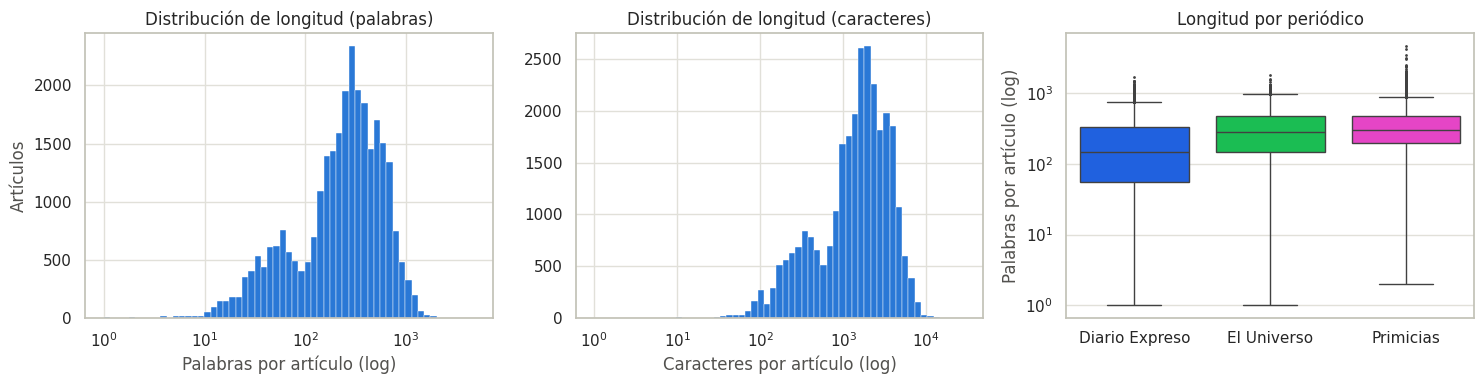

,n_palabras,n_caracteres
count,28777.0,28777.0
mean,316.0,1948.0
std,258.0,1583.0
min,1.0,1.0
25%,130.0,795.0
50%,263.0,1629.0
75%,443.0,2726.0
max,4746.0,29264.0


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

bins_palabras = np.logspace(np.log10(data["n_palabras"].clip(lower=1).min()),
                            np.log10(data["n_palabras"].max()), 60)
axes[0].hist(data["n_palabras"], bins=bins_palabras, color="#2a78d6", edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_xlabel("Palabras por artículo (log)")
axes[0].set_ylabel("Artículos")
axes[0].set_title("Distribución de longitud (palabras)")

bins_caracteres = np.logspace(np.log10(data["n_caracteres"].clip(lower=1).min()),
                              np.log10(data["n_caracteres"].max()), 60)
axes[1].hist(data["n_caracteres"], bins=bins_caracteres, color="#2a78d6", edgecolor="white", linewidth=0.3)
axes[1].set_xscale("log")
axes[1].set_xlabel("Caracteres por artículo (log)")
axes[1].set_title("Distribución de longitud (caracteres)")

orden_per = sorted(data["nombre_periodico"].unique())
sns.boxplot(data=data, x="nombre_periodico", y="n_palabras", order=orden_per,
            hue="nombre_periodico", hue_order=orden_per, palette=PALETA,
            legend=False, ax=axes[2], fliersize=1, linewidth=1)
axes[2].set_yscale("log")
axes[2].set_xlabel("")
axes[2].set_ylabel("Palabras por artículo (log)")
axes[2].set_title("Longitud por periódico")

plt.tight_layout()
plt.show()

data[["n_palabras", "n_caracteres"]].describe().round(0)

In [37]:
# Outliers en n_palabras según criterio IQR (1.5 * IQR)
q1 = data["n_palabras"].quantile(0.25)
q3 = data["n_palabras"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}")
print(f"Límites 'normales': [{limite_inferior:.0f}, {limite_superior:.0f}]")

outliers = data[(data["n_palabras"] < limite_inferior) | (data["n_palabras"] > limite_superior)]
print(f"\nTotal outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
print(f"  - por debajo (< {limite_inferior:.0f}): {(data['n_palabras'] < limite_inferior).sum()}")
print(f"  - por encima (> {limite_superior:.0f}): {(data['n_palabras'] > limite_superior).sum()}")

# Los más extremos por arriba (artículos larguísimos)
cols = [c for c in ["id_articulo", "titulo", "nombre_periodico", "seccion", "n_palabras", "n_caracteres"] if c in data.columns]
outliers.sort_values("n_palabras", ascending=False)[cols]


Q1=130  Q3=443  IQR=313
Límites 'normales': [-340, 912]

Total outliers: 856 (3.0%)
  - por debajo (< -340): 0
  - por encima (> 912): 856


,id_articulo,titulo,nombre_periodico,seccion,n_palabras,n_caracteres
22154,408727,Colombia | La Batalla Que Ganaron Las Big Tech...,Primicias,Política,4746,29264
5538,298581,20 Discos Que Siguen En La Memoria De Los Faná...,Primicias,Música,4273,25520
3511,435626,"Nvidia, La Mayor Empresa Del Mundo Por Capital...",Primicias,Ciencia-tecnologia,3513,21676
12239,228462,"Ibai Llanos, 'El Rey Midas De Internet', Diez ...",Primicias,Trending,3152,16858
17357,441666,"""Siempre Seremos Hijos De Europa"": ¿Por Qué El...",Primicias,Internacional,3066,19174
...,...,...,...,...,...,...
7997,460947,Estos Son Los Récords A Romper En El Mundial 2026,Primicias,Deportes,915,5352
22672,160260,Iess: Quejas Sin Resolver Hasta De Dos Décadas,Diario Expreso,Portada,914,5506
21421,167349,"Argentina, La Pieza Que Puede Reacomodar La Ge...",Primicias,Política,913,5617
25035,439799,Caso Malvinas | Cdh Acusa A Dos Fiscales Por P...,Primicias,Seguridad,913,5635


In [38]:
# Distribución fina de la cola baja: dimensiona cuántos artículos son teletipos, pies de
# foto o restos de maquetación. Motiva el umbral de descarte que se aplica en la sección 2.
for umbral in [5, 10, 20, 30, 40, 50, 60]:
    n = (data['n_palabras'] <= umbral).sum()
    print(f"<= {umbral:>3} palabras: {n:>5} artículos ({n/len(data)*100:.2f}%)")

print("\n--- Ejemplos de los más cortos ---")
cortos = data[data['n_palabras'] <= 50].sort_values('n_palabras').tail()
print(cortos[['n_palabras', 'texto']].to_string(index=False))

<=   5 palabras:    56 artículos (0.19%)
<=  10 palabras:   144 artículos (0.50%)
<=  20 palabras:   741 artículos (2.57%)
<=  30 palabras:  1571 artículos (5.46%)
<=  40 palabras:  2564 artículos (8.91%)
<=  50 palabras:  3450 artículos (11.99%)
<=  60 palabras:  4331 artículos (15.05%)

--- Ejemplos de los más cortos ---
 n_palabras                                                                                                                                                                                                                                                                                                                                                             texto
         50                                El primer semiconductor funcional hecho a partir de grafeno ha sido creado por investigadores de EE.UU. y China , una tecnología que podría permitir crear dispositivos más pequeños y rápidos, así como tener aplicaciones en computación cuántica. Expertos consideran q

## Cobertura muestral: año × periódico

Verificación del diseño estratificado (cuotas por estrato año × periódico).

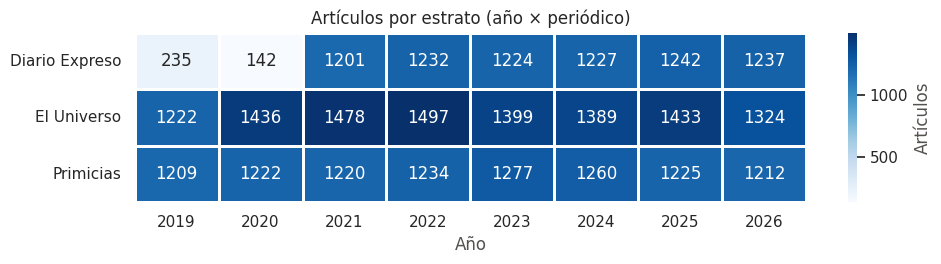

In [39]:
cobertura = data.pivot_table(index="nombre_periodico", columns="anio",
                             values="id_articulo", aggfunc="count", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 2.8))
sns.heatmap(cobertura, annot=True, fmt="d", cmap="Blues", linewidths=2,
            linecolor="white", cbar_kws={"label": "Artículos"}, ax=ax)
ax.set_xlabel("Año")
ax.set_ylabel("")
ax.set_title("Artículos por estrato (año × periódico)")
plt.tight_layout()
plt.show()

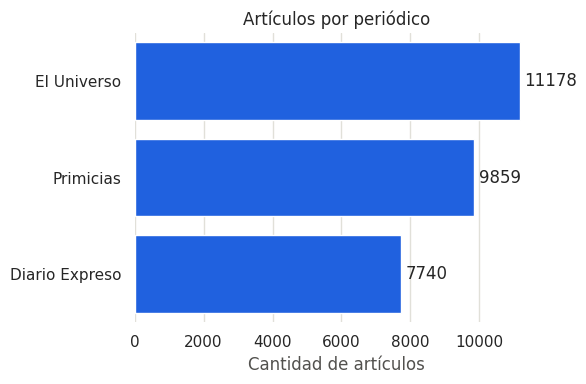

In [40]:
orden_per = data["nombre_periodico"].value_counts().index

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=data, y="nombre_periodico", order=orden_per, color=PALETA[0], ax=ax)
ax.set_xlabel("Cantidad de artículos")
ax.set_ylabel("")
ax.set_title("Artículos por periódico")

for cont in ax.containers:
    ax.bar_label(cont, padding=3)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## Secciones (crudas)

La sección viene como la titula cada periódico, así que es de **altísima cardinalidad**:
hay cientos de etiquetas distintas y la mayoría aparece en uno o dos artículos. Esto es
justo lo que motiva el mapeo a secciones canónicas de la sección 2 — como label de
clustering, la sección cruda es inservible.


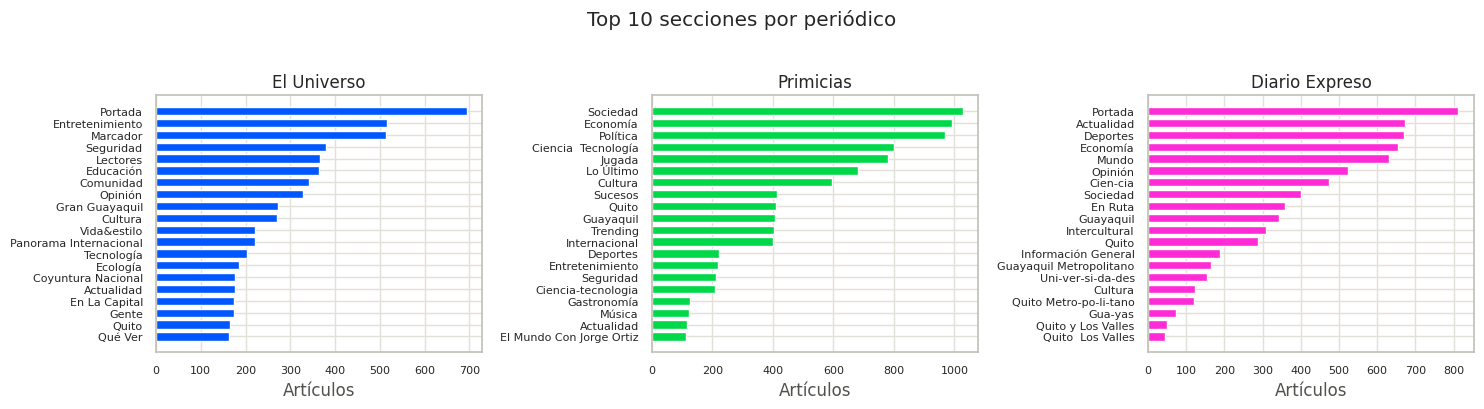

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, periodico, color in zip(axes, orden_per, PALETA):
    top = (data.loc[data["nombre_periodico"] == periodico, "seccion"]
           .value_counts().head(20).sort_values())
    ax.barh(top.index, top.values, color=color, height=0.7)
    ax.set_title(periodico)
    ax.set_xlabel("Artículos")
    ax.tick_params(labelsize=8)
plt.suptitle("Top 10 secciones por periódico", y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Por periódico: nº de secciones que aparecen una sola vez ("únicas") frente al total
# de secciones distintas, para dimensionar la cola de etiquetas de un solo artículo.
resumen = []
for periodico in orden_per:
    vc = data.loc[data["nombre_periodico"] == periodico, "seccion"].value_counts()
    resumen.append({
        "periodico": periodico,
        "secciones_totales": vc.size,
        "secciones_unicas": int((vc == 1).sum()),
        "%_unicas": round(100 * (vc == 1).mean(), 1),
    })

resumen = pd.DataFrame(resumen).set_index("periodico")
resumen


,secciones_totales,secciones_unicas,%_unicas
periodico,,,
El Universo,1631,1096,67.2
Primicias,145,68,46.9
Diario Expreso,179,55,30.7


## Serie temporal: artículos por mes

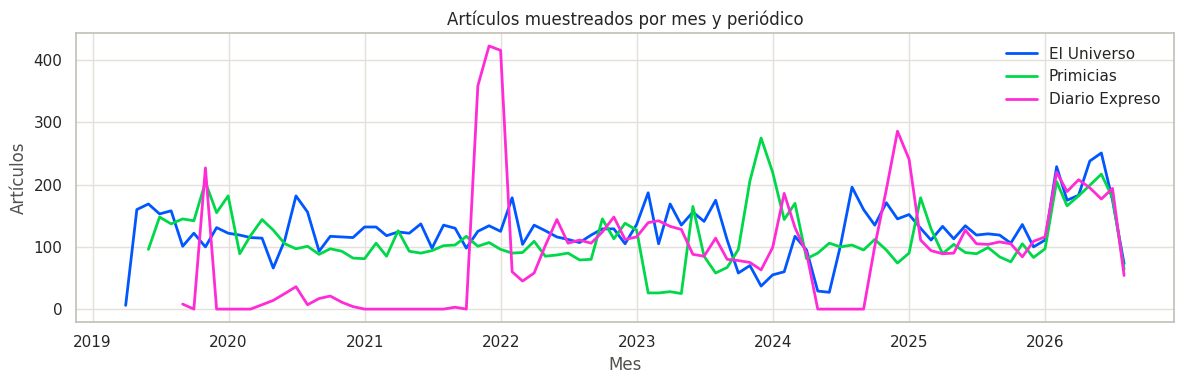

In [43]:
mensual = (data.set_index("fecha").groupby("nombre_periodico")
           .resample("ME")["id_articulo"].count().rename("articulos").reset_index())

fig, ax = plt.subplots(figsize=(12, 4))
for periodico, color in zip(orden_per, PALETA):
    serie = mensual[mensual["nombre_periodico"] == periodico]
    ax.plot(serie["fecha"], serie["articulos"], color=color, linewidth=2, label=periodico)
ax.set_xlabel("Mes")
ax.set_ylabel("Artículos")
ax.set_title("Artículos muestreados por mes y periódico")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Flags de incertidumbre y corrupción

- `u_index`, `economic_u_index`, `political_u_index`: flags de incertidumbre ya
  almacenadas en la BD de origen.
- `icor_v3_1_index`: flag de detección de corrupción (versión 3.1, con exclusión).

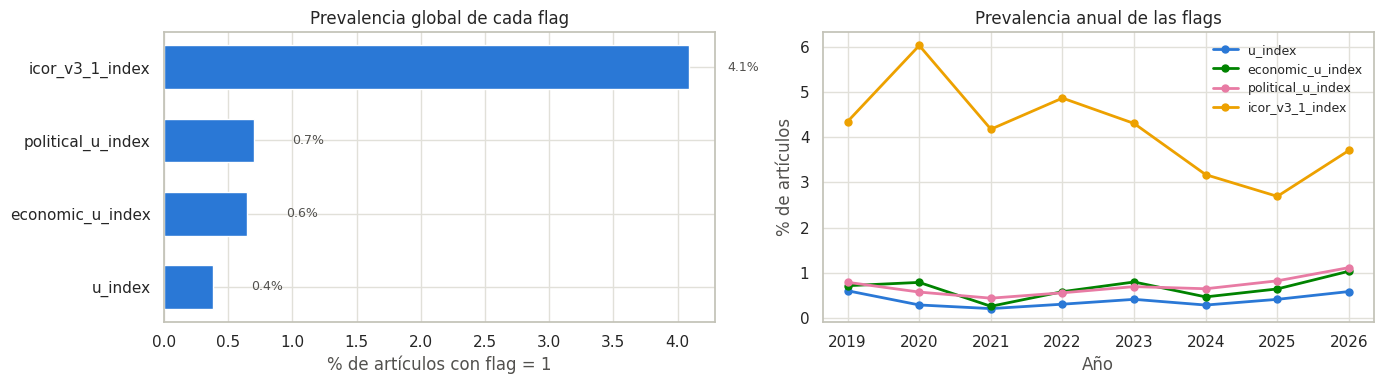

In [44]:
FLAGS = ["u_index", "economic_u_index", "political_u_index", "icor_v3_1_index"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

prevalencia = data[FLAGS].mean().sort_values() * 100
axes[0].barh(prevalencia.index, prevalencia.values, color="#2a78d6", height=0.6)
for i, v in enumerate(prevalencia.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9, color="#52514e")
axes[0].set_xlabel("% de artículos con flag = 1")
axes[0].set_title("Prevalencia global de cada flag")

anual = data.groupby("anio")[FLAGS].mean() * 100
colores_flags = ["#2a78d6", "#008300", "#e87ba4", "#eda100"]
for flag, color in zip(FLAGS, colores_flags):
    axes[1].plot(anual.index, anual[flag], color=color, linewidth=2, marker="o",
                 markersize=5, label=flag)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("% de artículos")
axes[1].set_title("Prevalencia anual de las flags")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

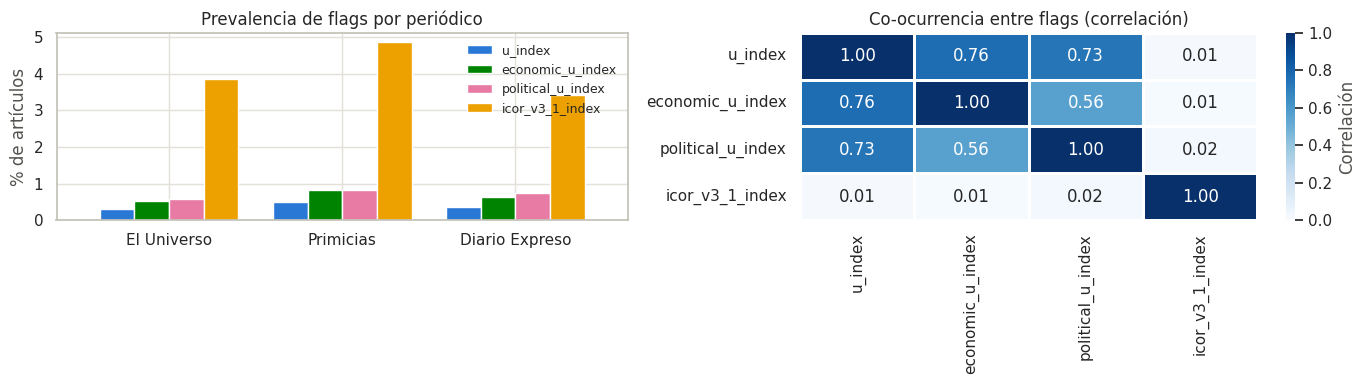

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

por_periodico = data.groupby("nombre_periodico")[FLAGS].mean().loc[orden_per] * 100
por_periodico.plot(kind="bar", ax=axes[0], color=colores_flags, width=0.8, edgecolor="white")
axes[0].set_xlabel("")
axes[0].set_ylabel("% de artículos")
axes[0].set_title("Prevalencia de flags por periódico")
axes[0].legend(frameon=False, fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

sns.heatmap(data[FLAGS].corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="white", ax=axes[1], cbar_kws={"label": "Correlación"})
axes[1].set_title("Co-ocurrencia entre flags (correlación)")

plt.tight_layout()
plt.show()

---
# 2. Data Wrangling

Aquí se aplican, en orden, todas las transformaciones que el EDA justificó:

1. **Normalización por campo** (limpieza de carácter).
2. **Deduplicación** sobre el texto normalizado.
3. **Sección canónica**: colapsa las secciones crudas a ~17 macro-secciones, que serán el
   label de referencia del clustering.
4. **Descarte de artículos de ≤40 palabras**.

A partir de aquí `data` **sí** se modifica; el EDA de arriba ya no es reproducible sobre el
`data` resultante.


## Normalización de texto

### Diseño de la normalización

La normalización se restringe a **limpieza de carácter**; los descartes por contenido
(crucigramas, artículos demasiado cortos) se hacen aparte, por fila. Se aplica **por campo**,
porque no todos alimentan lo mismo:

- `titulo` y `texto` se **embeben** (entran como `titulo + ". " + texto` al modelo) → reciben
  la normalización completa (`norm_text`).
- `seccion` es una **etiqueta categórica** que alimenta la canonicalización, no el modelo →
  recibe una versión ligera (`norm_label`): quita invisibles y recompone Unicode, pero **no**
  repara palabras pegadas ni pictogramas (irrelevante en una etiqueta), para no alterar el
  valor que se agrupa.

`norm_text` ejecuta, en orden deliberado (cada paso asume el anterior):

1. **Borrar caracteres invisibles/sin sentido:** soft hyphen (`\xad`), variation selectors
   (`\uFE0E\uFE0F`), zero-width y **Private Use Area** (`\uE000–\uF8FF`). Se eliminan (no se
   reemplazan por espacio) para volver a unir la palabra partida (`Actualidad → Actualidad`).
2. **Non-breaking hyphen (`\u2011`) → guión normal (`-`).**
3. **Normalización Unicode `NFC`** (no `NFKC`): recompone acentos descompuestos sin alterar
   comillas, `ñ`, ordinales ni cifras. `NFKC` se descartó porque convertiría `²`, `º`,
   ligaduras y fracciones, alterando datos numéricos legítimos sin beneficio aquí.
4. **Pictogramas de maquetación → espacio.** El `■`/`▶` aparecen también a media frase
   (`CULTURA■ Está preso`), así que se sustituyen por espacio, no se borran, para no volver a
   pegar palabras.
5. **Reparar palabras pegadas: `min.Mayus → min. Mayus`.** El patrón exige
   *minúscula + puntuación + Mayúscula*, lo que evita romper siglas (`FF.AA`), decimales
   (`4.759`) y dominios (`.com`). Es el paso con mayor superficie de error, por eso se acota al
   caso inequívoco.
6. **Minúsculas y colapso de espacios** (`\s+ → " "`), al final, para absorber los espacios
   que introdujeron los pasos 4 y 5.

**Lo que NO se normaliza (por diseño):** comillas y guiones tipográficos (cosmético para
tokenizers subword), el código `(I)/(O)` final (inofensivo tras minúsculas) y las palabras
pegadas sin puntuación (irrecuperables). Tras aplicar la función, re-ejecutar el diagnóstico
sobre el texto normalizado confirma que los invisibles y pictogramas caen a ~0; el residuo
esperado son esos tres casos.

In [46]:
import re
import unicodedata

# Pictogramas / viñetas de maquetación PressReader
_BASURA_PICTO = re.compile(r"[■⬛◼◗❚❑►▶▪●◉•‣·❏⬇◄▲▼★☆➤—―]")
# Invisibles / sin sentido: variation selectors, zero-width, direccionales y Private Use Area
_INVISIBLES = re.compile(r"[\uFE0E\uFE0F\u200B-\u200F\u202A-\u202E\uE000-\uF8FF]")


def _limpiar_invisibles(text: str) -> str:
    """Paso común: quita caracteres invisibles/sin sentido y recompone Unicode (NFC)."""
    text = text.replace("\xad", "")           # soft hyphen -> une palabra partida
    text = text.replace("\u2011", "-")        # non-breaking hyphen -> guión normal
    text = _INVISIBLES.sub("", text)          # variation selectors, zero-width, PUA (\uF07D)
    return unicodedata.normalize("NFC", text) # acentos descompuestos; NO altera comillas/ñ


def norm_text(text: str) -> str:
    """Normalización completa para contenido que se embebe (titulo, texto)."""
    text = _limpiar_invisibles(text)
    text = _BASURA_PICTO.sub(" ", text)                                      # pictogramas -> espacio
    text = re.sub(r"([a-záéíóúñ])([.,;:!?])([A-ZÁÉÍÓÚÑ])", r"\1\2 \3", text)  # min.Mayus -> min. Mayus
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def norm_label(text: str) -> str:
    """Normalización ligera para etiquetas categóricas (seccion): sin reparar pegados/pictos."""
    text = _limpiar_invisibles(text)
    text = _BASURA_PICTO.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


# --- Aplicación por campo ---
data["titulo_norm"]  = data["titulo"].fillna("").map(norm_text)
data["texto_norm"]   = data["texto"].map(norm_text)
data["seccion"]      = data["seccion"].fillna("").map(norm_label)  # antes de seccion_canonica


data["texto_diag"] = (data["titulo_norm"] + "\n" + data["seccion"] + "\n" + data["texto_norm"])
_ = diagnosticar_textos(data, col="texto_diag")

DIAGNÓSTICO — columna 'texto_diag', 28,777 textos
PATRÓN                                      DOCS       %  GRAVE
----------------------------------------------------------------------
Palabras pegadas (min.Mayus)                   0   0.00%
Soft hyphen \xad (parte palabras)              0   0.00%
Pictogramas de recuadro                        0   0.00%
Crucigrama (HORIZONTALES/VERTICALES)           0   0.00%
Comillas tipográficas                     12,325  42.83%
Guiones tipográficos                         976   3.39%
Código sección final (I)/(O)/(E)               0   0.00%
URLs                                         250   0.87%
Emails                                       102   0.35%
Acentos combinantes (no-NFC)                   0   0.00%
Viñetas numeradas ≥6 (listas)                214   0.74%
Runs de -- __ ..                              28   0.10%
Marker recuadro AL INICIO                      0   0.00%
Dígito pegado a letra (12años)               475   1.65%
-----------------

In [47]:
print("Duplicados tras normalizar:", int(data.duplicated(subset=["titulo_norm","texto_norm"]).sum()))

Duplicados tras normalizar: 1


In [48]:
data = data.drop_duplicates(subset=["titulo_norm","texto_norm"]).reset_index(drop=True)

In [49]:
data.drop(columns=["texto_diag"], inplace=True)

## Sección canónica

La sección cruda tiene ~1,700 valores distintos en esta muestra (~7,400 en la BD completa),
la mayoría con 1-3 artículos: no se puede usar como clase ni balancear. El mapeo canónico
la colapsa a **17 macro-secciones** mediante reglas por palabra clave sobre el nombre
normalizado, evaluadas en orden (la primera que matchea gana).

La lógica es una copia literal de
`scripts/sampling_for_clustering/sample_balanced_by_seccion.py` (`normalizar_seccion`,
`_REGLAS`, `mapear_seccion_canonica`). Se **copia y no se importa** porque ese script
depende de `config.get_sqlalchemy_url` y `src.utilities.text_utils`, módulos que no existen
en este repositorio.

**Por qué recalcularla aquí si el CSV ya la trae:** la columna `seccion_canonica` del CSV
viene precocinada por el script de muestreo, contra la sección **cruda** de la BD. Traer la
lógica al notebook la vuelve **auditable y afinable** — sin esto, el ~6-7% que cae en
`Otros` no se puede mejorar sin volver a la base de datos. La celda de verificación mide
si recalcularla sobre la sección ya normalizada cambia algo (no debería: `normalizar_seccion`
aplica NFKC + minúsculas y matchea por substring, así que ya absorbe soft hyphens y
pictogramas por su cuenta).

Nota: `Portada`, `Opinión` y `Actualidad` no son temas sino formato o posición en el
periódico, y `Otros` es un cajón de sastre. La sección 4 reporta las métricas con y sin
estas cuatro clases.


In [50]:
# --- Mapeo canónico de sección ---
# Copia literal de scripts/sampling_for_clustering/sample_balanced_by_seccion.py
# (normalizar_seccion, _REGLAS, mapear_seccion_canonica). Ver nota arriba sobre por qué se
# copia en vez de importarse.
import re
import unicodedata


def normalizar_seccion(s: str) -> str:
    """Normaliza el nombre de sección para el matching de reglas.

    Quita soft-hyphens, aplica NFKC, unifica separadores (& -> ' y ', '-' -> ' '),
    colapsa espacios y pasa a minúsculas.
    """
    if not isinstance(s, str):
        return ""
    s = s.replace("\xad", "")  # soft-hyphen
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("&", " y ").replace("-", " ")
    return re.sub(r"\s+", " ", s).strip().lower()


# Reglas por palabra clave (substring sobre el nombre normalizado). Orden = prioridad:
# la primera que matchea gana. Cubren la cabeza y la cola larga.
_REGLAS = [
    ("Deportes", ("deporte", "jugada", "marcador", "futbol", "fútbol",
                  "eliminatoria", "mundial", "olimp",
                  "juegos", "liga", "copa")),
    ("Economía", ("económ", "economia", "economía", "negocio", "entorno económico",
                  "enfoque económico", "mercado", "finanz")),
    ("Política", ("polít", "politic", "legislat", "elecc", "asamblea",
                  "coyuntura nacional", "acontecer nacional", "hechos del país",
                  "debate", "gobierno", "presidencial")),
    ("Seguridad", ("segurid", "suceso", "delict", "violent", "muerte", "crimen",
                   "expediente", "narco", "conflicto")),
    ("Ciencia y Tecnología", ("ciencia", "tecnolog", "tecno", "digital", "innovac")),
    ("Vida y Estilo", ("vida y estilo", "vida estilo", "vidayestilo", "estilo",
                       "gastronom", "moda", "salud", "bienestar", "en ruta",
                       "hogar", "familia")),
    ("Cultura", ("cultura", "música", "musica", "cine", "arte", "libro",
                 "literatura", "gente", "patrimonio")),
    ("Entretenimiento", ("entreten", "farándula", "farandula", "trending", "diversión", "diversion",
                         "qué ver", "que ver", "espectác", "espectac", "tv",
                         "televisión", "viral")),
    ("Mundo", ("mundo", "internacional", "panorama internacional", "el país",
               "el mundo", "global", "migra")),
    ("Local Guayaquil", ("guayaquil", "guayas", "gran guayaquil")),
    ("Local Quito", ("quito", "capital", "los valles", "pichincha")),
    ("Educación", ("educ", "universidad", "escolar")),
    ("Sociedad", ("sociedad", "comunidad", "intercultural", "información general",
                  "informacion general", "ecología", "ecologia", "ambiente",
                  "en la ciudad")),
    # No temáticas (se evalúan al final para no capturar prefijos temáticos).
    ("Portada", ("portada",)),
    ("Opinión", ("opinión", "opinion", "lectores", "editorial", "columna")),
    ("Actualidad", ("actualidad", "lo último", "lo ultimo", "hoy", "última hora")),
]


def mapear_seccion_canonica(seccion: str) -> str:
    """Mapea una sección cruda a su sección canónica (o 'Otros')."""
    norm = normalizar_seccion(seccion)
    if not norm:
        return "Otros"
    for canonica, claves in _REGLAS:
        if any(clave in norm for clave in claves):
            return canonica
    return "Otros"

In [51]:
# Verificación: ¿recalcular la canónica sobre la sección ya normalizada cambia algo frente
# a la columna que trae el CSV? Se mide ANTES de sobrescribirla, para no perder la referencia.
canonica_regen = data["seccion"].map(mapear_seccion_canonica)
difieren = canonica_regen != data["seccion_canonica"]

print(f"Filas que cambian de clase al regenerar: {difieren.sum()} "
      f"({difieren.mean() * 100:.3f}%)")
if difieren.any():
    print("\nCasos que cambian (seccion -> del CSV / regenerada):")
    print(data.loc[difieren, ["seccion", "seccion_canonica"]]
          .assign(regenerada=canonica_regen[difieren])
          .value_counts().head(15).to_string())

data["seccion_canonica"] = canonica_regen

Filas que cambian de clase al regenerar: 107 (0.372%)

Casos que cambian (seccion -> del CSV / regenerada):
seccion    seccion_canonica  regenerada     
Diversión  Deportes          Entretenimiento    107


In [52]:
# Auditoría del mapeo: distribución por clase, cobertura fuera de 'Otros' y las secciones
# crudas que más caen en 'Otros' (es la lista para afinar _REGLAS sin salir del notebook).
conteos = data["seccion_canonica"].value_counts()
n_otros = conteos.get("Otros", 0)

print("Distribución por sección canónica:")
print(conteos.to_string())
print(f"\nClases: {conteos.size}  |  cobertura fuera de 'Otros': "
      f"{(len(data) - n_otros) / len(data) * 100:.1f}% "
      f"({len(data) - n_otros:,} de {len(data):,})")

otros_crudos = data.loc[data["seccion_canonica"] == "Otros", "seccion"].value_counts()
print(f"\nTop secciones crudas que caen en 'Otros' ({otros_crudos.size} distintas):")
print(otros_crudos.head(25).to_string())

Distribución por sección canónica:
seccion_canonica
Economía                2390
Sociedad                2361
Deportes                2317
Cultura                 2013
Otros                   2000
Mundo                   1865
Ciencia y Tecnología    1859
Actualidad              1761
Local Guayaquil         1657
Política                1632
Portada                 1507
Entretenimiento         1442
Local Quito             1396
Seguridad               1318
Vida y Estilo           1278
Opinión                 1231
Educación                749

Clases: 17  |  cobertura fuera de 'Otros': 93.0% (26,776 de 28,776)

Top secciones crudas que caen en 'Otros' (1104 distintas):
seccion
El Universo                        34
Especial                           25
Domingo                            22
Pasatiempos                        22
Patrocinado                        21
Front Page                         19
Garage                             19
Revistagestion                     16
Época Invernal

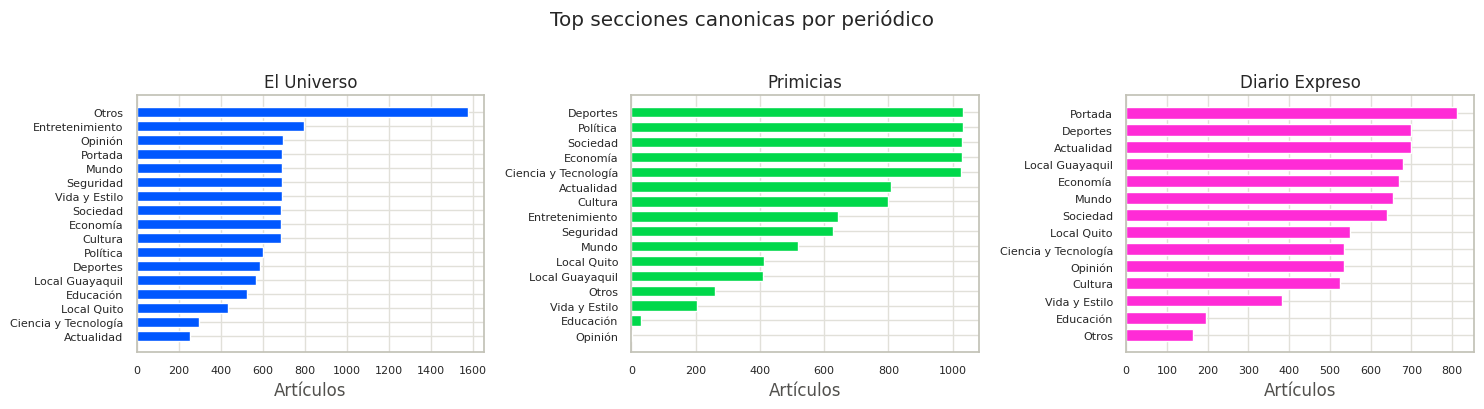

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, periodico, color in zip(axes, orden_per, PALETA):
    top = (data.loc[data["nombre_periodico"] == periodico, "seccion_canonica"]
           .value_counts().sort_values())
    ax.barh(top.index, top.values, color=color, height=0.7)
    ax.set_title(periodico)
    ax.set_xlabel("Artículos")
    ax.tick_params(labelsize=8)
plt.suptitle("Top secciones canonicas por periódico", y=1.02)
plt.tight_layout()
plt.show()

### La sección canónica como label del clustering

Estas 17 clases son la **referencia externa** con la que se evalúa el clustering en la
sección 4. Conviene ser explícito sobre qué son y qué no:

**Por qué sirven:**

- Es la **única etiqueta temática disponible** en el corpus. La alternativa, `seccion`
  cruda, tiene ~1,700 valores distintos y no se puede usar como clase.
- Tras el colapso quedan clases de **volumen comparable** (del orden de cientos a un par de
  miles de artículos cada una), porque `sample_grid_balanced.py` ya aplanó la sección
  dentro de cada celda año × periódico. Sin ese aplanado, el desbalance en el pool crudo
  llega a ~58×, y cualquier métrica supervisada estaría dominada por dos o tres clases.
- Permiten métricas **externas** (ARI, AMI, homogeneidad, completitud) que responden a la
  pregunta que importa: *¿la estructura que encuentra el clustering no supervisado se
  parece a la organización temática que hacen los periódicos?*

**Por qué NO son ground truth — y hay que decirlo al interpretar:**

- La etiqueta la asigna el periódico por criterio **editorial y de maquetación**, no por
  contenido: un mismo hecho puede ir en «Actualidad», en «Portada» o en la sección local
  según el día y el medio.
- El mapeo canónico es por **substring** sobre el nombre de página, así que hereda los
  errores de ese nombre y añade los suyos (una página «Mundial de fútbol» cae en Deportes,
  pero «Mundo» y «mundial» comparten prefijo con reglas distintas — de ahí que el orden de
  `_REGLAS` sea parte de la definición).
- Cuatro clases no son temas: `Portada` y `Actualidad` son posición o inmediatez,
  `Opinión` es género, `Otros` es residuo. Mezclan contenido heterogéneo por construcción.

**Consecuencia práctica:** un ARI bajo es ambiguo. Puede significar que el clustering
falló, o que encontró una partición temática **mejor** que la editorial. Por eso la sección
4 reporta las métricas en dos vistas —las 17 clases y solo las 13 temáticas— y acompaña
siempre las métricas externas con las internas y con el % de ruido.


## Descarte de artículos demasiado cortos

El EDA mostró una cola baja de artículos de pocas palabras: teletipos, pies de foto,
sumarios y restos de maquetación que no son artículos. Para embeddings y clustering son
ruido puro —un texto de 15 palabras produce un vector dominado por dos o tres términos— así
que se descartan los de **≤40 palabras**.

El umbral es una decisión de corte: 40 palabras es aproximadamente un titular más una
entradilla, el mínimo para que un embedding capture algo de tema. Se verifica abajo que el
descarte no se concentre en una sección o un periódico, lo que sesgaría el corpus.


In [54]:
# Longitudes sobre el texto YA normalizado (las del EDA eran sobre el crudo).
data["n_caracteres"] = data["texto_norm"].str.len()
data["n_palabras"] = data["texto_norm"].str.split().str.len()

MIN_PALABRAS = 40
descartados = data[data["n_palabras"] <= MIN_PALABRAS]
n_antes = len(data)

print(f"Artículos con <= {MIN_PALABRAS} palabras: {len(descartados):,} "
      f"({len(descartados) / n_antes * 100:.2f}%)")

# ¿El descarte sesga alguna clase? Se compara la tasa de descarte por grupo con la global.
tasa_global = len(descartados) / n_antes
for col in ["nombre_periodico", "seccion_canonica"]:
    tasa = (data.groupby(col)["n_palabras"].apply(lambda s: (s <= MIN_PALABRAS).mean())
            .sort_values(ascending=False) * 100)
    print(f"\n% descartado por {col} (global: {tasa_global * 100:.2f}%):")
    print(tasa.round(2).to_string())

print("\n--- Ejemplos de artículos descartados ---")
print(descartados[["n_palabras", "titulo", "texto_norm"]]
      .sort_values("n_palabras", ascending=False).head(5).to_string(index=False))

Artículos con <= 40 palabras: 2,566 (8.92%)

% descartado por nombre_periodico (global: 8.92%):
nombre_periodico
Diario Expreso    15.34
El Universo        9.26
Primicias          3.49

% descartado por seccion_canonica (global: 8.92%):
seccion_canonica
Educación               16.29
Vida y Estilo           15.18
Otros                   13.20
Sociedad                12.45
Local Guayaquil         12.37
Local Quito             11.89
Economía                11.13
Actualidad               8.52
Seguridad                7.81
Ciencia y Tecnología     7.75
Deportes                 7.73
Portada                  7.70
Mundo                    7.40
Entretenimiento          5.27
Cultura                  4.72
Política                 2.39
Opinión                  1.22

--- Ejemplos de artículos descartados ---
 n_palabras                                      titulo                                                                                                                                          

In [55]:
# `reset_index(drop=True)`: la sección 4 indexa con `data.iloc[i]` a partir de posiciones
# de los embeddings, así que el índice debe quedar 0..N-1 sin huecos.
data = data[data["n_palabras"] > MIN_PALABRAS].reset_index(drop=True)

print(f"Corpus limpio: {len(data):,} artículos (de {n_antes:,} antes del filtro)")
print(f"Secciones canónicas: {data['seccion_canonica'].nunique()} "
      f"| nulos: {int(data['seccion_canonica'].isna().sum())}")
print(f"\nLongitud tras la limpieza:")
print(data[["n_palabras", "n_caracteres"]].describe().round(0).to_string())

Corpus limpio: 26,210 artículos (de 28,776 antes del filtro)
Secciones canónicas: 17 | nulos: 0

Longitud tras la limpieza:
       n_palabras  n_caracteres
count     26210.0       26210.0
mean        347.0        2121.0
std         255.0        1550.0
min          41.0         209.0
25%         165.0        1010.0
50%         288.0        1762.0
75%         476.0        2902.0
max        4747.0       29182.0


---
# 3. Embeddings

Los cinco métodos principales y la ablación se calculan sobre el corpus completo ya
limpio. Cada caché guarda los `id_articulo` y una huella que incluye texto, modelo,
revisión, contexto, prefijo, instrucción, task adapter, overlap, pooling, agregación,
normalización, precisión y versión de la lógica.

Los checkpoints parciales usan la misma huella: si cambia cualquiera de esas decisiones,
el parcial se invalida automáticamente. No es necesario borrar archivos a mano.

In [ ]:
# Entrada común: título + texto normalizados, en el mismo orden que `data`.
textos = (data["titulo_norm"] + ". " + data["texto_norm"]).tolist()

# Tokenizador léxico compartido solo por c-TF-IDF y coherencia temática. Los modelos de
# embedding usan cada uno su tokenizador subpalabra oficial.
_PATRON_TOKEN = re.compile(r"(?u)\b\w\w+\b")
print(
    f"{len(textos):,} textos | palabras: mín {data['n_palabras'].min()}, "
    f"mediana {data['n_palabras'].median():.0f}, máx {data['n_palabras'].max()}"
)
print(f"\nEjemplo:\n{textos[0][:300]}…")

In [ ]:
import hashlib
import json
from pathlib import Path

EMB_DIR = RAIZ / "data" / "embeddings"
EMB_DIR.mkdir(parents=True, exist_ok=True)
ids_full = data["id_articulo"].to_numpy()


import functools


@functools.lru_cache(maxsize=1)
def _huella_base_textos() -> str:
    """Calcula la huella SHA-256 del corpus de textos una sola vez en memoria."""
    h = hashlib.sha256()
    for t in textos:
        h.update(t.encode("utf-8"))
        h.update(b"\x00")
    return h.hexdigest()


def huella_corpus(params: dict | None = None) -> str:
    """SHA-256 del contenido de `textos` más los parámetros del método.

    Los `id_articulo` NO bastan como clave de caché: si cambia la normalización del texto
    (`norm_text`) o la tokenización de un método, los ids siguen siendo exactamente los
    mismos, el caché se da por bueno y el notebook sigue con vectores obsoletos SIN NINGÚN
    error visible — desalineados con lo que el resto del pipeline cree estar analizando.
    La huella cierra ese agujero: cualquier cambio en el texto o en los parámetros que
    afectan al embedding produce una huella distinta y fuerza el recálculo.
    """
    h = hashlib.sha256(_huella_base_textos().encode("utf-8"))
    h.update(json.dumps(params or {}, sort_keys=True, default=str).encode("utf-8"))
    return h.hexdigest()


def cargar_cache_full(nombre: str, params: dict | None = None) -> np.ndarray | None:
    """Devuelve el embedding cacheado solo si corresponde exactamente al corpus actual."""
    ruta_emb = EMB_DIR / f"{nombre}_full.npy"
    ruta_ids = EMB_DIR / f"{nombre}_full_ids.npy"
    ruta_meta = EMB_DIR / f"{nombre}_full_meta.json"

    if not (ruta_emb.exists() and ruta_ids.exists()):
        return None
    if not np.array_equal(np.load(ruta_ids), ids_full):
        print(f"Caché descartado ({nombre}): los id_articulo no coinciden con el corpus actual.")
        return None
    if not ruta_meta.exists():
        print(f"Caché SIN HUELLA ({nombre}): se generó antes de esta salvaguarda, así que no "
              f"se puede verificar contra el texto actual. Se ignora y se recalcula.\n"
              f"  Si te consta que `textos` NO ha cambiado desde que se generó, evita el "
              f"recálculo con:  adoptar_cache_full({nombre!r})")
        return None

    esperada = huella_corpus(params)
    guardada = json.loads(ruta_meta.read_text()).get("huella", "")
    if guardada != esperada:
        print(f"Caché descartado ({nombre}): cambió el texto del corpus o los parámetros del "
              f"método (huella {guardada[:12]}… != {esperada[:12]}…). Se recalcula.")
        return None

    print(f"Caché válido: {ruta_emb}")
    return np.load(ruta_emb)


def guardar_cache_full(nombre: str, emb: np.ndarray, params: dict | None = None) -> None:
    np.save(EMB_DIR / f"{nombre}_full.npy", emb)
    np.save(EMB_DIR / f"{nombre}_full_ids.npy", ids_full)
    (EMB_DIR / f"{nombre}_full_meta.json").write_text(
        json.dumps({"huella": huella_corpus(params), "n": len(ids_full),
                    "params": params or {}}, ensure_ascii=False, indent=1))


def adoptar_cache_full(nombre: str, params: dict | None = None) -> None:
    """Estampa la huella actual sobre un caché YA existente, sin recalcularlo.

    Solo sirve para migrar cachés generados antes de esta salvaguarda. Úsalo únicamente si
    te consta que `textos` no ha cambiado desde que se generaron: si sí cambió, esto sella
    como válidos unos vectores obsoletos, que es justo lo que la huella existe para evitar.
    """
    ruta_emb = EMB_DIR / f"{nombre}_full.npy"
    if not ruta_emb.exists():
        print(f"No hay caché que adoptar en {ruta_emb}")
        return
    np.save(EMB_DIR / f"{nombre}_full_ids.npy", ids_full)
    (EMB_DIR / f"{nombre}_full_meta.json").write_text(
        json.dumps({"huella": huella_corpus(params), "n": len(ids_full),
                    "params": params or {}, "adoptado": True}, ensure_ascii=False, indent=1))
    print(f"Caché adoptado: {nombre} (huella estampada sin recalcular)")


def huella_parcial(nombre: str) -> Path:
    """Sidecar del checkpoint reanudable. El parcial no guarda ids ni longitud fiable, así
    que sin esto un parcial de otra corrida se daría por bueno y dejaría los vectores
    desalineados en silencio."""
    return EMB_DIR / f"{nombre}_full_parcial_huella.txt"


def parcial_valido(nombre: str, params: dict | None = None) -> bool:
    ruta = huella_parcial(nombre)
    return ruta.exists() and ruta.read_text().strip() == huella_corpus(params)


def sellar_parcial(nombre: str, params: dict | None = None) -> None:
    huella_parcial(nombre).write_text(huella_corpus(params))

## Modelos de embedding y arquitectura común

`EmbeddingSpec` contiene toda decisión que afecta el resultado y, por tanto, la huella
del caché. `EmbeddingRunner` implementa carga, inferencia, checkpoints y liberación de
GPU. El chunking y la agregación son funciones puras reutilizadas por todos los modelos.

La comparación principal usa cada arquitectura bajo su configuración recomendada. La
instrucción de Qwen3 es neutral: no menciona incertidumbre, economía, política,
corrupción ni las secciones editoriales usadas como referencia.

In [ ]:
from __future__ import annotations

import gc
import inspect
from dataclasses import asdict, dataclass, replace
from importlib.metadata import version
from typing import Literal

import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from packaging.version import Version
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
from transformers import AutoTokenizer

from src.llm_clients import get_embedding_client, load_config


EMBEDDING_LOGIC_VERSION = "document-embedding-v4-2026-08-01"
TOKEN_BUDGET_MARGIN = 4  # evita truncamiento por cambios decode -> retokenize en fronteras
QWEN_CLUSTER_PROMPT = (
    "Instruct: Identify categories in Spanish-language news articles "
    "according to their main topic.\nQuery:"
)


@dataclass(frozen=True)
class EmbeddingSpec:
    """Contrato completo de un método texto -> vector.

    La configuración es inmutable y forma parte de la huella del caché. `prompt` y
    `input_prefix` son distintos: SentenceTransformers inserta el primero mediante
    `prompt=`, mientras que E5 requiere añadir literalmente `query: ` a cada entrada.
    """

    name: str
    model_id: str
    cache_name: str
    max_tokens: int
    output_dim: int
    batch_size: int
    article_block_size: int
    overlap_tokens: int = 64
    input_prefix: str = ""
    prompt: str | None = None
    task: str | None = None
    prompt_name: str | None = None
    trust_remote_code: bool = False
    padding_side: Literal["left", "right"] | None = None
    revision: str | None = None
    is_ablation: bool = False
    backend: Literal["sentence_transformers", "vllm"] = "sentence_transformers"

    def cache_params(self, precision: str) -> dict:
        return {
            "embedding_logic_version": EMBEDDING_LOGIC_VERSION,
            "token_budget_margin": TOKEN_BUDGET_MARGIN,
            "precision": precision,
            "pooling": "native_model_pooling",
            "chunk_aggregation": "l2_new_token_weighted_l2",
            "normalize_embeddings": True,
            **asdict(self),
        }


MODELOS_PRINCIPALES = {
    "BGE-M3": EmbeddingSpec(
        name="BGE-M3",
        model_id="BAAI/bge-m3",
        cache_name="bge_m3_native",
        max_tokens=8192,
        output_dim=1024,
        batch_size=32,  # tamaño de lote por request HTTP al servidor vLLM (LOTE=32 pre-refactor)
        article_block_size=640,  # = 20 lotes de 32, cadencia de checkpoint probada pre-refactor
        backend="vllm",
    ),
    "Jina-v3": EmbeddingSpec(
        name="Jina-v3",
        model_id="jinaai/jina-embeddings-v3",
        cache_name="jina_v3_separation",
        max_tokens=8192,
        output_dim=1024,
        batch_size=64,
        article_block_size=800,
        task="separation",
        prompt_name="separation",
        trust_remote_code=True,
    ),
    "E5-large": EmbeddingSpec(
        name="E5-large",
        model_id="intfloat/multilingual-e5-large",
        cache_name="multilingual_e5_large_query",
        max_tokens=512,
        output_dim=1024,
        batch_size=128,
        article_block_size=1500,
        overlap_tokens=64,
        input_prefix="query: ",
    ),
    "Qwen3-instruct": EmbeddingSpec(
        name="Qwen3-instruct",
        model_id="Qwen/Qwen3-Embedding-0.6B",
        cache_name="qwen3_06b_topic_instruction",
        max_tokens=32768,
        output_dim=1024,
        batch_size=16,
        article_block_size=400,
        prompt=QWEN_CLUSTER_PROMPT,
        padding_side="left",
    ),
    "Jina-v2-ES": EmbeddingSpec(
        name="Jina-v2-ES",
        model_id="jinaai/jina-embeddings-v2-base-es",
        cache_name="jina_v2_base_es",
        max_tokens=8192,
        output_dim=768,
        batch_size=64,
        article_block_size=800,
        trust_remote_code=True,
    ),
}

ABLACIONES_EMBEDDING = {
    "Qwen3-no-instruct": replace(
        MODELOS_PRINCIPALES["Qwen3-instruct"],
        name="Qwen3-no-instruct",
        cache_name="qwen3_06b_no_instruction",
        prompt=None,
        is_ablation=True,
    )
}
TODOS_LOS_MODELOS = {**MODELOS_PRINCIPALES, **ABLACIONES_EMBEDDING}


def _normalizar_filas(X: np.ndarray) -> np.ndarray:
    return normalize(np.asarray(X, dtype=np.float32), norm="l2").astype(np.float32)


def _overhead_tokens(spec: EmbeddingSpec, tokenizer, prompt_resuelto: str = "") -> int:
    """Tokens no pertenecientes al artículo: especiales + prefijo/prompt."""
    especiales = int(tokenizer.num_special_tokens_to_add(pair=False))
    if spec.model_id.startswith("Qwen/"):
        especiales = max(especiales, 1)  # el embedding de Qwen usa el estado de EOS
    texto_extra = f"{spec.input_prefix}{prompt_resuelto or spec.prompt or ''}"
    extra = len(tokenizer(texto_extra, add_special_tokens=False)["input_ids"]) if texto_extra else 0
    return especiales + extra


def dividir_ids_con_cobertura(
    token_ids: list[int],
    content_budget: int,
    overlap_tokens: int,
) -> list[tuple[list[int], int]]:
    """Divide ids sin perder la cola y devuelve (chunk, tokens_nuevos).

    El peso es la cobertura nueva real, no la longitud total de la ventana. Por ello,
    los tokens del overlap no reciben peso doble y el último chunk corto no queda
    sobrerrepresentado.
    """
    if content_budget < 1:
        raise ValueError("El prompt/especiales consumen toda la ventana del modelo.")
    if not 0 <= overlap_tokens < content_budget:
        raise ValueError("overlap_tokens debe estar entre 0 y content_budget - 1.")
    if not token_ids:
        return [([], 1)]

    paso = content_budget - overlap_tokens
    chunks: list[tuple[list[int], int]] = []
    cubierto_hasta = 0
    for inicio in range(0, len(token_ids), paso):
        fin = min(inicio + content_budget, len(token_ids))
        nuevos = max(0, fin - cubierto_hasta)
        if nuevos:
            chunks.append((token_ids[inicio:fin], nuevos))
            cubierto_hasta = fin
        if fin == len(token_ids):
            break
    assert cubierto_hasta == len(token_ids), "El chunking no cubrió todos los tokens."
    return chunks


def preparar_articulo(
    texto: str,
    spec: EmbeddingSpec,
    tokenizer,
    prompt_resuelto: str = "",
) -> tuple[list[str], np.ndarray]:
    ids = tokenizer(texto, add_special_tokens=False, truncation=False)["input_ids"]
    presupuesto = (
        spec.max_tokens
        - _overhead_tokens(spec, tokenizer, prompt_resuelto)
        - TOKEN_BUDGET_MARGIN
    )
    partes = dividir_ids_con_cobertura(ids, presupuesto, spec.overlap_tokens)
    chunks = [
        spec.input_prefix
        + tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )
        for chunk_ids, _ in partes
    ]
    pesos = np.asarray([nuevos for _, nuevos in partes], dtype=np.float32)
    return chunks, pesos


def agregar_chunks(vectores: np.ndarray, pesos: np.ndarray) -> np.ndarray:
    vectores = _normalizar_filas(vectores)
    pesos = np.asarray(pesos, dtype=np.float32)
    if len(vectores) != len(pesos) or len(vectores) == 0:
        raise ValueError("Vectores y pesos de chunks no están alineados.")
    documento = np.average(vectores, axis=0, weights=pesos)
    norma = np.linalg.norm(documento)
    if not np.isfinite(norma) or norma == 0:
        raise ValueError("Embedding documental inválido tras agregar chunks.")
    return (documento / norma).astype(np.float32)


class EmbeddingRunner:
    """Carga un único modelo, respeta su pooling nativo y libera memoria al terminar."""

    def __init__(self, spec: EmbeddingSpec, device: str | None = None):
        self.spec = spec
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model: SentenceTransformer | None = None
        self.tokenizer = None
        self.prompt_resuelto = ""
        self._cliente = None
        self._modelo_remoto = None
        # BGE-M3 corre en el servidor vLLM remoto: su huella de caché no debe depender de
        # si la máquina local tiene GPU o no.
        self.precision = (
            "remote" if self.spec.backend == "vllm"
            else "float16" if self.device.startswith("cuda") else "float32"
        )

    def __enter__(self):
        if self.spec.backend == "vllm":
            config = load_config()
            self._cliente = get_embedding_client(config)
            self._modelo_remoto = config.embedding_model
            self.tokenizer = AutoTokenizer.from_pretrained(
                self.spec.model_id,
                trust_remote_code=self.spec.trust_remote_code,
                revision=self.spec.revision,
                padding_side=self.spec.padding_side or "right",
            )
            return self

        kwargs = {
            "device": self.device,
            "trust_remote_code": self.spec.trust_remote_code,
        }
        if self.spec.revision:
            kwargs["revision"] = self.spec.revision
        if self.spec.padding_side:
            kwargs["tokenizer_kwargs"] = {"padding_side": self.spec.padding_side}
        if self.device.startswith("cuda"):
            kwargs["model_kwargs"] = {"torch_dtype": torch.float16}

        self.model = SentenceTransformer(self.spec.model_id, **kwargs)
        self.model.max_seq_length = self.spec.max_tokens
        self.tokenizer = self.model.tokenizer
        if self.spec.padding_side:
            self.tokenizer.padding_side = self.spec.padding_side
        if self.spec.prompt_name:
            self.prompt_resuelto = self.model.prompts.get(self.spec.prompt_name, "")

        firma_encode = inspect.signature(self.model.encode)
        acepta_kwargs = any(
            p.kind == inspect.Parameter.VAR_KEYWORD
            for p in firma_encode.parameters.values()
        )
        if self.spec.task and "task" not in firma_encode.parameters and not acepta_kwargs:
            raise RuntimeError(
                f"{self.spec.name} requiere una versión de sentence-transformers "
                "que admita encode(..., task=...)."
            )
        return self

    def __exit__(self, exc_type, exc, tb):
        self.model = None
        self.tokenizer = None
        self._cliente = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def encode(self, entradas: list[str]) -> np.ndarray:
        if self.spec.backend == "vllm":
            if self._cliente is None:
                raise RuntimeError("Usa EmbeddingRunner como context manager.")
            vectores: list[list[float]] = []
            for i in range(0, len(entradas), self.spec.batch_size):
                lote = entradas[i : i + self.spec.batch_size]
                respuesta = self._cliente.embeddings.create(
                    model=self._modelo_remoto, input=lote
                )
                vectores.extend(d.embedding for d in respuesta.data)
            return _normalizar_filas(np.asarray(vectores, dtype=np.float32))

        if self.model is None:
            raise RuntimeError("Usa EmbeddingRunner como context manager.")
        kwargs = {
            "batch_size": self.spec.batch_size,
            "show_progress_bar": False,
            "convert_to_numpy": True,
            "normalize_embeddings": True,
        }
        if self.spec.prompt is not None:
            kwargs["prompt"] = self.spec.prompt
        if self.spec.task is not None:
            kwargs["task"] = self.spec.task
        if self.spec.prompt_name is not None:
            kwargs["prompt_name"] = self.spec.prompt_name
        salida = np.asarray(self.model.encode(entradas, **kwargs), dtype=np.float32)
        return _normalizar_filas(salida)

    def generar_documentos(self, textos: list[str]) -> np.ndarray:
        """Genera/reanuda un vector por artículo con checkpoints alineados por posición."""
        params = self.spec.cache_params(self.precision)
        cache = cargar_cache_full(self.spec.cache_name, params)
        if cache is not None:
            validar_embeddings(cache, self.spec, len(textos))
            return cache

        ruta_parcial = EMB_DIR / f"{self.spec.cache_name}_full_parcial.npy"
        if ruta_parcial.exists() and not parcial_valido(self.spec.cache_name, params):
            print(f"Parcial incompatible de {self.spec.name}: se descarta.")
            ruta_parcial.unlink()
            huella_parcial(self.spec.cache_name).unlink(missing_ok=True)

        salida = list(np.load(ruta_parcial)) if ruta_parcial.exists() else []
        if len(salida) >= len(textos):
            salida = []
        inicio = len(salida)
        if inicio:
            print(f"Reanudando {self.spec.name}: {inicio:,}/{len(textos):,}")

        bloques = range(inicio, len(textos), self.spec.article_block_size)
        for b0 in tqdm(bloques, desc=self.spec.name):
            bloque = textos[b0 : b0 + self.spec.article_block_size]
            entradas_planas: list[str] = []
            pesos_por_articulo: list[np.ndarray] = []
            for texto in bloque:
                chunks, pesos = preparar_articulo(
                    texto, self.spec, self.tokenizer, self.prompt_resuelto
                )
                entradas_planas.extend(chunks)
                pesos_por_articulo.append(pesos)

            vecs = self.encode(entradas_planas)
            cursor = 0
            for pesos in pesos_por_articulo:
                siguiente = cursor + len(pesos)
                salida.append(agregar_chunks(vecs[cursor:siguiente], pesos))
                cursor = siguiente
            assert cursor == len(vecs)

            np.save(ruta_parcial, np.asarray(salida, dtype=np.float32))
            sellar_parcial(self.spec.cache_name, params)

        emb = np.asarray(salida, dtype=np.float32)
        validar_embeddings(emb, self.spec, len(textos))
        guardar_cache_full(self.spec.cache_name, emb, params)
        ruta_parcial.unlink(missing_ok=True)
        huella_parcial(self.spec.cache_name).unlink(missing_ok=True)
        return emb


def validar_embeddings(emb: np.ndarray, spec: EmbeddingSpec, n_esperado: int) -> None:
    emb = np.asarray(emb)
    if emb.shape != (n_esperado, spec.output_dim):
        raise ValueError(
            f"{spec.name}: shape {emb.shape}; se esperaba {(n_esperado, spec.output_dim)}."
        )
    if not np.isfinite(emb).all():
        raise ValueError(f"{spec.name}: hay NaN o infinitos.")
    normas = np.linalg.norm(emb, axis=1)
    if not np.allclose(normas, 1.0, atol=2e-3):
        raise ValueError(
            f"{spec.name}: los vectores no quedaron L2-normalizados "
            f"(normas {normas.min():.4f}–{normas.max():.4f})."
        )


if Version(version("sentence-transformers")) < Version("3.1.0"):
    raise RuntimeError("Se requiere sentence-transformers>=3.1.0 para Jina v3.")
if Version(version("transformers")) < Version("4.51.0"):
    raise RuntimeError("Se requiere transformers>=4.51.0 para Qwen3 Embedding.")

## Diagnóstico de longitudes por tokenizador

Antes de inferir se cuantifica cuánto texto cabe realmente en cada modelo, incluidos
tokens especiales, prefijos e instrucciones. Esto evita asumir que palabras y subwords
son equivalentes y permite detectar cualquier artículo que necesite chunking.

In [ ]:
def diagnosticar_longitudes(textos, specs: dict[str, EmbeddingSpec]) -> pd.DataFrame:
    """Diagnóstico por tokenizador antes de inferencia; no carga pesos de los modelos."""
    filas = []
    for nombre, spec in specs.items():
        tokenizer = AutoTokenizer.from_pretrained(
            spec.model_id,
            trust_remote_code=spec.trust_remote_code,
            revision=spec.revision,
            padding_side=spec.padding_side or "right",
        )
        batch_tok = 4000
        largos_list = []
        for i in tqdm(range(0, len(textos), batch_tok), desc=f"Tokenizando {nombre}"):
            lote = textos[i : i + batch_tok]
            encoded = tokenizer(lote, add_special_tokens=False, truncation=False, return_attention_mask=False)
            largos_list.extend(len(ids) for ids in encoded["input_ids"])
        largos = np.asarray(largos_list, dtype=np.int32)
        overhead = _overhead_tokens(spec, tokenizer)
        presupuesto = spec.max_tokens - overhead - TOKEN_BUDGET_MARGIN
        paso = presupuesto - spec.overlap_tokens
        chunks = np.where(
            largos <= presupuesto,
            1,
            1 + np.ceil((largos - presupuesto) / paso).astype(int),
        )
        q = np.percentile(largos, [50, 90, 95, 99, 100])
        filas.append(
            {
                "modelo": nombre,
                "contexto": spec.max_tokens,
                "overhead": overhead,
                "presupuesto_texto": presupuesto,
                "p50": q[0],
                "p90": q[1],
                "p95": q[2],
                "p99": q[3],
                "max": q[4],
                "% > 512": 100 * np.mean(largos > 512),
                "% > 8192": 100 * np.mean(largos > 8192),
                "% > 32768": 100 * np.mean(largos > 32768),
                "% un_forward": 100 * np.mean(largos <= presupuesto),
                "chunks_media": chunks.mean(),
                "chunks_max": chunks.max(),
            }
        )
        del tokenizer
    return pd.DataFrame(filas).set_index("modelo")


diagnostico_longitudes = diagnosticar_longitudes(textos, TODOS_LOS_MODELOS)
display(diagnostico_longitudes.round(2))

## Generación reanudable de embeddings

Se genera un vector normalizado por artículo. E5 añade `query:` a cada chunk; Jina v3
activa `separation`; Qwen3 usa last-token pooling a través de su implementación oficial
de SentenceTransformers. La cola nunca se descarta y el overlap no recibe peso doble.

In [ ]:
# Los cinco modelos principales forman la comparación. Qwen3-no-instruct se genera y
# evalúa aparte: es una ablación, no una sexta oportunidad de ganar.
MODELOS_A_EJECUTAR = [*MODELOS_PRINCIPALES, *ABLACIONES_EMBEDDING]

embeddings_generados = {}
for nombre in MODELOS_A_EJECUTAR:
    spec = TODOS_LOS_MODELOS[nombre]
    print(f"\n{'=' * 72}\n{nombre}: {spec.model_id}\n{'=' * 72}")
    with EmbeddingRunner(spec) as runner:
        embeddings_generados[nombre] = runner.generar_documentos(textos)
    print(f"{nombre}: {embeddings_generados[nombre].shape}")

metodos = {
    nombre: embeddings_generados[nombre]
    for nombre in MODELOS_PRINCIPALES
}
embeddings_ablacion = {
    nombre: embeddings_generados[nombre]
    for nombre in ABLACIONES_EMBEDDING
}

assert list(metodos) == list(MODELOS_PRINCIPALES)
assert set(metodos).isdisjoint(embeddings_ablacion)
print(f"\nComparación principal: {list(metodos)}")
print(f"Ablaciones: {list(embeddings_ablacion)}")

## Diagnóstico PCA de cada espacio de embedding

PCA no asigna significado a las dimensiones originales: construye componentes nuevas
ordenadas por varianza. Se reportan el espectro, la varianza acumulada, los componentes
necesarios para 80/90/95/99 %, la varianza retenida por 15 componentes y la dimensión
efectiva. Este diagnóstico no decide por sí solo la dimensión de UMAP, que preserva
vecindarios de forma no lineal.

In [ ]:
from sklearn.preprocessing import normalize


PCA_UMBRALES = (0.80, 0.90, 0.95, 0.99)
PCA_MAX_ARTICULOS = None  # None = espectro exacto; usa 12_000 si necesitas reducir coste


def diagnostico_pca_embedding(
    emb: np.ndarray,
    *,
    max_articulos: int | None = PCA_MAX_ARTICULOS,
    random_state: int = RANDOM_STATE,
) -> dict:
    """Espectro PCA completo sobre el mismo embedding L2-normalizado usado al clusterizar.

    Se diagonaliza la matriz de covarianza D x D. Las dimensiones originales no son
    interpretables ni están ordenadas; las componentes principales sí se ordenan por
    varianza explicada.
    """
    X = normalize(np.asarray(emb, dtype=np.float32))
    if max_articulos is not None and len(X) > max_articulos:
        rng = np.random.default_rng(random_state)
        idx = np.sort(rng.choice(len(X), max_articulos, replace=False))
        X = X[idx]
    X = X.astype(np.float64, copy=False)
    X -= X.mean(axis=0, keepdims=True)
    cov = (X.T @ X) / max(len(X) - 1, 1)
    autovalores = np.linalg.eigvalsh(cov)[::-1]
    autovalores = np.clip(autovalores, 0, None)
    ratio = autovalores / autovalores.sum()
    acumulada = np.cumsum(ratio)
    ks = {
        f"k{int(100 * umbral)}": int(np.searchsorted(acumulada, umbral) + 1)
        for umbral in PCA_UMBRALES
    }
    dim_efectiva = float(autovalores.sum() ** 2 / np.square(autovalores).sum())
    return {
        "n_articulos": len(X),
        "dim_original": X.shape[1],
        "autovalores": autovalores,
        "ratio": ratio,
        "acumulada": acumulada,
        "var_pca15": float(acumulada[min(14, len(acumulada) - 1)]),
        "dim_efectiva": dim_efectiva,
        **ks,
    }


espacios_pca = {**metodos, **embeddings_ablacion}
pca_resultados = {
    nombre: diagnostico_pca_embedding(emb)
    for nombre, emb in tqdm(espacios_pca.items(), desc="Diagnóstico PCA")
}

tabla_pca = pd.DataFrame(
    {
        nombre: {
            "tipo": "ablación" if nombre in embeddings_ablacion else "principal",
            "n_articulos": r["n_articulos"],
            "dim_original": r["dim_original"],
            "var_PCA15": r["var_pca15"],
            "k80": r["k80"],
            "k90": r["k90"],
            "k95": r["k95"],
            "k99": r["k99"],
            "%dim_k95": 100 * r["k95"] / r["dim_original"],
            "dim_efectiva": r["dim_efectiva"],
        }
        for nombre, r in pca_resultados.items()
    }
).T
display(tabla_pca.round(3))

# Una fila por espacio: scree plot y varianza acumulada.
n = len(pca_resultados)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.3 * n), squeeze=False)
for fila, (nombre, r) in enumerate(pca_resultados.items()):
    n_scree = min(100, len(r["ratio"]))
    axes[fila, 0].plot(
        np.arange(1, n_scree + 1),
        r["ratio"][:n_scree],
        linewidth=1.5,
    )
    axes[fila, 0].set_title(f"{nombre} — varianza por componente (primeras {n_scree})")
    axes[fila, 0].set_xlabel("Componente principal")
    axes[fila, 0].set_ylabel("Varianza explicada")

    x = np.arange(1, len(r["acumulada"]) + 1)
    axes[fila, 1].plot(x, r["acumulada"], linewidth=1.6)
    for umbral in PCA_UMBRALES:
        axes[fila, 1].axhline(umbral, color="gray", alpha=0.25, linewidth=0.8)
    axes[fila, 1].axvline(15, color="red", linestyle="--", linewidth=1, label="15D")
    axes[fila, 1].set_ylim(0, 1.01)
    axes[fila, 1].set_title(f"{nombre} — varianza acumulada")
    axes[fila, 1].set_xlabel("Número de componentes")
    axes[fila, 1].set_ylabel("Varianza acumulada")
plt.tight_layout()
plt.show()

# Comparación directa del número de componentes requerido por cada umbral.
tabla_k = tabla_pca[["k80", "k90", "k95", "k99"]].astype(float)
ax = tabla_k.plot(kind="bar", figsize=(13, 5), width=0.8)
ax.set_ylabel("Componentes principales")
ax.set_title("Dimensionalidad PCA necesaria para retener la varianza")
ax.legend(title="Varianza acumulada")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Visualización 3D complementaria: PCA y UMAP

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from umap import UMAP


def proyectar(emb):
    """PCA-3 y UMAP-3 para visualización; no se reutilizan para clusterizar."""
    emb_norm = normalize(emb)
    red3 = PCA(n_components=3, random_state=RANDOM_STATE)
    xyz_pca = red3.fit_transform(emb_norm)
    var3 = red3.explained_variance_ratio_.sum()

    # PCA-50 acelera solo esta visualización 3D; no forma parte de las dos variantes
    # de clustering definidas más adelante.
    x50 = PCA(
        n_components=min(50, emb_norm.shape[1]),
        random_state=RANDOM_STATE,
    ).fit_transform(emb_norm)
    xyz_umap = UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=RANDOM_STATE,
    ).fit_transform(x50)
    return xyz_pca, xyz_umap, var3


proyecciones = {
    nombre: proyectar(emb)
    for nombre, emb in metodos.items()
}
print(f"Proyecciones calculadas para {len(proyecciones)} modelos principales.")

In [ ]:
def plot_proyecciones(color_por: str, titulo: str, colores: dict, etiquetas: dict):
    # Una fila por método: el número de filas se deriva de `proyecciones`, nunca fijo,
    # para que añadir un método no lo deje fuera del gráfico en silencio.
    nfilas = len(proyecciones)
    fig, axes = plt.subplots(nfilas, 2, figsize=(15, 5.8 * nfilas), squeeze=False,
                             subplot_kw={"projection": "3d"})
    for fila, (nombre, (xyz_pca, xyz_umap, var3)) in enumerate(proyecciones.items()):
        vistas = [(xyz_pca, f"PCA ({var3:.0%} var.)"), (xyz_umap, "UMAP")]
        for col, (xyz, tipo) in enumerate(vistas):
            ax = axes[fila, col]
            for valor, color in colores.items():
                mascara = (data[color_por] == valor).to_numpy()
                ax.scatter(xyz[mascara, 0], xyz[mascara, 1], xyz[mascara, 2],
                           s=5, alpha=0.25, color=color, label=etiquetas[valor],
                           linewidths=0)
            ax.set_title(f"{nombre} — {tipo}", fontsize=11)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_zticklabels([])
    handles, labels_leg = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper center", ncol=min(len(colores), 6),
               frameon=False, bbox_to_anchor=(0.5, 1.0), markerscale=8)
    fig.suptitle(titulo, y=1.01, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()


plot_proyecciones("nombre_periodico", "Embeddings coloreados por periódico",
                  dict(zip(orden_per, PALETA)), {p: p for p in orden_per})

In [ ]:
# Colorear por sección canónica: las 8 clases temáticas más frecuentes; el resto va a
# "Otras" en gris de fondo (con 17 colores el gráfico deja de ser legible).
NO_TEMATICAS = {"Portada", "Opinión", "Actualidad", "Otros"}
top_secciones = (data.loc[~data["seccion_canonica"].isin(NO_TEMATICAS), "seccion_canonica"]
                 .value_counts().head(8).index.tolist())
print("Secciones destacadas:", top_secciones)

data["seccion_top"] = data["seccion_canonica"].where(
    data["seccion_canonica"].isin(top_secciones), "Otras")

# Paleta secundaria
PALETA_SEC = ["#0057ff", "#ff6a00", "#00c853", "#ff2bd6",
              "#ffb300", "#00bcd4", "#ffe600", "#111111"]
colores_sec = {"Otras": "#dedcd2", **dict(zip(top_secciones, PALETA_SEC))}

plot_proyecciones("seccion_top",
                  "Embeddings coloreados por sección canónica (top 8 temáticas)",
                  colores_sec, {v: v for v in colores_sec})

In [ ]:
plot_proyecciones("u_index", "Embeddings coloreados por flag de incertidumbre (u_index)",
                  COLOR_FLAG, {0: "sin incertidumbre", 1: "con incertidumbre"})

### Lectura de las proyecciones

- Estas vistas 3D son exploratorias; no sustituyen el espectro PCA ni las métricas de
  clustering.
- Si los colores por periódico se mezclan dentro de los grupos, la estructura dominante
  parece temática y no meramente editorial.
- La vista por sección canónica anticipa cuánto puede coincidir el clustering con esa
  taxonomía, pero una partición válida puede descubrir temas más finos o transversales.
- La ablación Qwen3 sin instrucción se analiza en las tablas, no se añade a estas figuras
  principales para no darle el mismo estatus que a los cinco modelos.

---
# 4. Clustering — HDBSCAN con y sin UMAP

Cada uno de los cinco modelos principales se evalúa mediante dos rutas:

1. `embedding L2 -> UMAP-15 (coseno) -> HDBSCAN (euclídea)`;
2. `embedding L2 -> HDBSCAN (euclídea)` directamente.

Ambas conservan `min_cluster_size`, `min_samples`, `cluster_selection_method="eom"` y la
misma semilla. El objetivo es aislar cuánto cambia la partición por introducir UMAP. La
variante UMAP registra además *trustworthiness* sobre una muestra fija.

Se usa el paquete standalone `hdbscan` porque expone `condensed_tree_`,
`single_linkage_tree_`, `validity_index` (DBCV) y membresías probabilísticas.

## Jerarquía de métricas

- **Nivel 1 — decisión:** AMI frente a `seccion_canonica`, DBCV, Silhouette coseno en el
  embedding original y coherencia NPMI.
- **Nivel 2 — contexto:** número y tamaño de clusters, porcentaje de ruido y confianza.
- **Nivel 3 — reporte:** ARI, NMI, V-measure, homogeneidad, completitud y $C_v$.
- **Nivel 4 — anexo:** Davies–Bouldin, Calinski–Harabasz y Silhouette en el espacio donde
  HDBSCAN fue ajustado.

Las métricas geométricas se interpretan junto con el porcentaje de ruido. AMI corrige por
azar y es preferible a NMI/V-measure para comparar cortes con distinto número de clusters.
Las secciones editoriales son etiquetas externas ruidosas, no *ground truth*: una
granularidad temática válida puede obtener ARI bajo si subdivide una sección amplia.

## Jerarquía y clustering probabilístico

Cada configuración hace un único fit EOM y corta `single_linkage_tree_` a diferentes
distancias para inspeccionar niveles jerárquicos. `all_points_membership_vectors` y
`probabilities_` describen la pertenencia suave y la fuerza del cluster duro; no se usan
para reasignar automáticamente el ruido.

La coherencia se calcula solo para la partición EOM. c-TF-IDF y NPMI comparten el mismo
tokenizador léxico para que términos y coocurrencias pertenezcan al mismo vocabulario.

In [ ]:
# --- Constantes, corpus de coherencia y helpers de métricas ---
import hdbscan
from sklearn.preprocessing import normalize
from umap import UMAP
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             calinski_harabasz_score, davies_bouldin_score,
                             homogeneity_completeness_v_measure,
                             normalized_mutual_info_score, silhouette_score)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from IPython.display import display
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

MIN_CLUSTER_SIZE  = 100   # tamaño mínimo de un cluster "real"
MIN_SAMPLES       = 10    # mayor => más puntos marcados como ruido
N_MUESTRA_METRICA = 8000  # silhouette/DBCV necesitan la matriz de distancias completa
N_MUESTRA_TRUSTWORTHINESS = 5000
UMAP_CLUSTER_N_COMPONENTS = 15
UMAP_CLUSTER_N_NEIGHBORS = 50
UMAP_CLUSTER_MIN_DIST = 0.0
VARIANTES_CLUSTERING = ("umap", "original")
N_CORTES          = 12    # niveles del barrido de cortes del árbol; subir para la corrida final
TOP_TERMINOS      = 10    # términos c-TF-IDF por cluster
COLS_VERDAD       = ["seccion", "seccion_canonica"]   # etiquetas externas, ambas ruidosas

# Corpus de coherencia, construido una sola vez con el mismo tokenizador léxico que
# `terminos_por_cluster`. Que coincidan no es cosmético: la
# coherencia es una medida relacional entre los términos top de un cluster y los conteos de
# co-ocurrencia del corpus, así que si cada pieza llamara "palabra" a algo distinto el
# número no significaría nada. `textos` ya viene en minúsculas desde norm_text (celda 36).
tokens_coh = [_PATRON_TOKEN.findall(t) for t in textos]
dicc_coh = Dictionary(tokens_coh)
dicc_coh.filter_extremes(no_below=5, no_above=0.5)   # elimina rarezas y términos ubicuos


def _descriptivas(labels):
    """n_clusters, %_ruido y tamaños de cluster. Nivel 2: contexto obligatorio."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = int((labels == -1).sum())
    tam = np.bincount(labels[labels >= 0]) if (labels >= 0).any() else np.array([0])
    return {
        "n_clusters": n_clusters,
        "%_ruido": 100 * n_ruido / len(labels),
        "tam_min": int(tam.min()), "tam_med": int(np.median(tam)), "tam_max": int(tam.max()),
    }


def _internas(X_cluster, emb_norm, labels, rng, variante):
    """Métricas internas sobre una submuestra común, excluyendo ruido.

    `silhouette_cos` siempre se calcula en el embedding original L2-normalizado y es la
    referencia comparable. DB/CH/DBCV y `silhouette_cluster` describen el espacio donde
    HDBSCAN fue ajustado: UMAP-15 o el embedding original.
    """
    sin_ruido = labels != -1
    if sin_ruido.sum() < 2 or len(set(labels[sin_ruido])) < 2:
        return {}
    idx = np.flatnonzero(sin_ruido)
    if len(idx) > N_MUESTRA_METRICA:
        idx = rng.choice(idx, N_MUESTRA_METRICA, replace=False)
    y = labels[idx]
    if len(set(y)) < 2:
        return {}
    salida = {
        "silhouette_cos": silhouette_score(emb_norm[idx], y, metric="cosine"),
        "silhouette_cluster": silhouette_score(X_cluster[idx], y, metric="euclidean"),
        "davies_bouldin": davies_bouldin_score(X_cluster[idx], y),
        "calinski_harabasz": calinski_harabasz_score(X_cluster[idx], y),
    }
    salida["silhouette_umap"] = (
        salida["silhouette_cluster"] if variante == "umap" else np.nan
    )
    return salida


def _dbcv(X, labels, rng):
    """DBCV (validity_index) sobre submuestra; requiere float64 y matriz de distancias.

    Cambio respecto al código exploratorio previo: se excluye el ruido ANTES de
    submuestrear (antes se submuestreaba sobre todos los puntos, incluido el ruido), para
    que todas las internas (silhouette, DB, CH, DBCV) hablen del mismo subconjunto de
    puntos "clusterizados".
    """
    sin_ruido = labels != -1
    if sin_ruido.sum() < 2 or len(set(labels[sin_ruido])) < 2:
        return np.nan
    idx = np.flatnonzero(sin_ruido)
    if len(idx) > N_MUESTRA_METRICA:
        idx = rng.choice(idx, N_MUESTRA_METRICA, replace=False)
    y = labels[idx]
    if len(set(y) - {-1}) < 2:
        return np.nan
    try:
        return hdbscan.validity.validity_index(X[idx].astype(np.float64), y)
    except Exception as e:            # DBCV falla si un cluster queda con 1 punto
        print(f"  (DBCV no calculable: {e})")
        return np.nan


def _externas(labels, data, cols=COLS_VERDAD):
    """ARI/AMI/NMI/V/homogeneidad/completitud contra cada columna de `cols`.

    AMI_{col} es nivel 1 (decide); el resto es nivel 3 (se reporta, no decide).
    El ruido (-1) cuenta como una categoría más en `labels`, igual que antes: ignorarlo
    premiaría a los métodos que descartan lo difícil. No hay subdivisión 17/13 clases ni
    métrica de pureza: se eliminaron en este refactor.
    """
    salida = {}
    for col in cols:
        y_true = data[col].to_numpy()
        y_pred = labels
        h, c, v = homogeneity_completeness_v_measure(y_true, y_pred)
        salida[f"AMI_{col}"] = adjusted_mutual_info_score(y_true, y_pred)
        salida[f"ARI_{col}"] = adjusted_rand_score(y_true, y_pred)
        salida[f"NMI_{col}"] = normalized_mutual_info_score(y_true, y_pred)
        salida[f"V_{col}"] = v
        salida[f"homog_{col}"] = h
        salida[f"compl_{col}"] = c
    return salida

# Las funcionales se quitan por LISTA, no por IDF. Con K≈49 clases, `de` pesa ~0.017 en
# c-TF-IDF y un término exclusivo de un cluster solo lo supera si aparece >600 veces en el
# corpus: la fórmula corrige el df saturado y el sesgo de tamaño, pero no cierra la brecha
# de tf. `textos` viene de norm_text: minúsculas y CON acentos (NFC), así que la lista de
# NLTK (que trae "más", "también") matchea tal cual, sin desacentuar nada.
_STOPWORDS_ES = sorted(set(stopwords.words("spanish")))


def terminos_por_cluster(labels, textos, top_n=TOP_TERMINOS):
    """c-TF-IDF de clase: cada cluster es un pseudo-documento y el peso de un término es su
    frecuencia RELATIVA en la clase por un IDF calculado contra su frecuencia GLOBAL en el
    corpus, no contra el número de clases:

        tf(t,c) = f(t,c) / Σ_t' f(t',c)     # normaliza por tamaño del cluster
        idf(t)  = ln(1 + A / f(t))          # A = palabras promedio por clase

    Frente al `TfidfVectorizer` que había aquí antes, arregla dos cosas: (1) el df ya no se
    satura — con solo K pseudo-documentos, todo término común aparece en los K y su idf
    queda clavado en el mínimo (1.0) sin suprimir nada, que es la razón por la que los
    términos top salían siendo `de, la, el, que`; (2) el tf ya no es conteo bruto, así que
    no premia a los clusters grandes.

    NO se usa `min_df`: sobre pseudo-documentos cuenta en cuántos CLUSTERES aparece el
    término, así que filtraría justo los exclusivos de un cluster — los mejores
    descriptores. Todo el filtrado de vocabulario lo hace `stop_words`.
    """
    clusters_validos = sorted(set(labels) - {-1})
    if not clusters_validos:
        return {}
    pseudo_docs = [
        " ".join(textos[i] for i in np.flatnonzero(labels == c))
        for c in clusters_validos
    ]

    vectorizador = CountVectorizer(
        token_pattern=_PATRON_TOKEN.pattern,   # mismo tokenizador que la coherencia
        stop_words=_STOPWORDS_ES,
    )
    C = vectorizador.fit_transform(pseudo_docs).astype(np.float64)   # csr [K, V], se queda sparse
    vocab = np.array(vectorizador.get_feature_names_out())

    palabras_por_clase = np.maximum(np.asarray(C.sum(axis=1)).ravel(), 1.0)   # [K]
    frec_global = np.maximum(np.asarray(C.sum(axis=0)).ravel(), 1.0)          # [V]
    A = palabras_por_clase.mean()

    idf = np.log1p(A / frec_global)
    ctfidf = C.multiply(1.0 / palabras_por_clase[:, None]).multiply(idf[None, :]).tocsr()

    resultado = {}
    for fila, c in enumerate(clusters_validos):
        pesos = ctfidf.getrow(fila).toarray().ravel()
        top_idx = np.argpartition(pesos, -top_n)[-top_n:]
        top_idx = top_idx[np.argsort(pesos[top_idx])[::-1]]
        resultado[c] = [vocab[i] for i in top_idx if pesos[i] > 0]
    return resultado


def _coherencia(terminos, tokens=tokens_coh, dicc=dicc_coh):
    """NPMI (principal, nivel 1) y C_v (nivel 3) sobre los términos top por cluster.

    Filtra los términos ausentes del diccionario de coherencia antes de pasarlos a gensim
    (revienta si un tópico queda vacío) y descarta tópicos que queden con <2 términos tras
    el filtro. Si no quedan tópicos válidos devuelve NaN en ambas.
    """
    topics = []
    for terms in terminos.values():
        filtrados = [t for t in terms if t in dicc.token2id]
        if len(filtrados) >= 2:
            topics.append(filtrados)

    if not topics:
        return {"npmi": np.nan, "cv": np.nan}

    try:
        npmi = CoherenceModel(topics=topics, texts=tokens, dictionary=dicc,
                              coherence="c_npmi").get_coherence()
    except Exception as e:
        print(f"  (NPMI no calculable: {e})")
        npmi = np.nan
    try:
        cv = CoherenceModel(topics=topics, texts=tokens, dictionary=dicc,
                            coherence="c_v").get_coherence()
    except Exception as e:
        print(f"  (C_v no calculable: {e})")
        cv = np.nan
    return {"npmi": npmi, "cv": cv}

In [ ]:
# --- Núcleo reutilizable: HDBSCAN con y sin reducción UMAP ---
def analizar_espacio(
    emb,
    nombre,
    data,
    *,
    variante="umap",
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    n_cortes=N_CORTES,
    coherencia=True,
    plots=True,
    random_state=RANDOM_STATE,
) -> dict:
    """Clustering, jerarquía, membresía probabilística y métricas para un espacio.

    `variante="umap"` ejecuta L2 -> UMAP-15 -> HDBSCAN.
    `variante="original"` ejecuta L2 -> HDBSCAN directamente. En ambas se mantienen
    exactamente los mismos hiperparámetros HDBSCAN para aislar el efecto de UMAP.
    """
    if variante not in VARIANTES_CLUSTERING:
        raise ValueError(f"Variante desconocida: {variante}")
    assert len(emb) == len(data), "El orden de emb y data no coincide."
    nombre_config = f"{nombre}__{variante}"
    print(
        f"\n{'=' * 72}\n{nombre_config} — {np.asarray(emb).shape}\n{'=' * 72}"
    )
    rng = np.random.default_rng(random_state)
    emb_norm = normalize(emb)

    if variante == "umap":
        X = UMAP(
            n_components=UMAP_CLUSTER_N_COMPONENTS,
            n_neighbors=UMAP_CLUSTER_N_NEIGHBORS,
            min_dist=UMAP_CLUSTER_MIN_DIST,
            metric="cosine",
            random_state=random_state,
        ).fit_transform(emb_norm)
        n_tw = min(N_MUESTRA_TRUSTWORTHINESS, len(X))
        idx_tw = np.sort(rng.choice(len(X), n_tw, replace=False))
        trust = trustworthiness(
            emb_norm[idx_tw],
            X[idx_tw],
            n_neighbors=min(UMAP_CLUSTER_N_NEIGHBORS, n_tw - 1),
            metric="cosine",
        )
    else:
        X = emb_norm
        trust = np.nan

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
        gen_min_span_tree=True,
        prediction_data=True,
    ).fit(X)
    labels_eom = clusterer.labels_

    n_clusters_eom = len(set(labels_eom)) - (1 if -1 in labels_eom else 0)
    n_ruido_eom = int((labels_eom == -1).sum())
    print(
        f"EOM — clusters: {n_clusters_eom} | ruido: {n_ruido_eom:,} "
        f"({n_ruido_eom / len(labels_eom):.1%})"
    )
    if variante == "umap":
        print(f"Trustworthiness UMAP: {trust:.4f}")
    if n_clusters_eom:
        tam = np.bincount(labels_eom[labels_eom >= 0])
        print(
            f"Tamaños — mín {tam.min()}, mediana {int(np.median(tam))}, "
            f"máx {tam.max()}"
        )

    # Barrido de cortes sobre el árbol generado en el espacio de esta variante.
    tree_df = clusterer.single_linkage_tree_.to_pandas()
    distancias = tree_df["distance"].to_numpy()
    distancias = distancias[np.isfinite(distancias) & (distancias > 0)]
    cuantiles = np.linspace(0.50, 0.999, n_cortes)
    cortes_dist = np.quantile(distancias, cuantiles)

    filas_barrido = []
    n_clusters_vistos = set()
    for d in cortes_dist:
        labels_nivel = clusterer.single_linkage_tree_.get_clusters(
            cut_distance=d,
            min_cluster_size=min_cluster_size,
        )
        n_cl = len(set(labels_nivel)) - (1 if -1 in labels_nivel else 0)
        if n_cl < 2 or n_cl in n_clusters_vistos:
            continue
        n_clusters_vistos.add(n_cl)

        fila = {
            "metodo": nombre_config,
            "modelo": nombre,
            "variante": variante,
            "nivel": "corte",
            "distancia_corte": d,
        }
        fila.update(_descriptivas(labels_nivel))
        fila.update(_internas(X, emb_norm, labels_nivel, rng, variante))
        fila["dbcv"] = _dbcv(X, labels_nivel, rng)
        fila.update(_externas(labels_nivel, data))
        filas_barrido.append(fila)

    metricas_eom = {}
    metricas_eom.update(_descriptivas(labels_eom))
    metricas_eom.update(_internas(X, emb_norm, labels_eom, rng, variante))
    metricas_eom["dbcv"] = _dbcv(X, labels_eom, rng)
    metricas_eom.update(_externas(labels_eom, data))

    fila_eom = {
        "metodo": nombre_config,
        "modelo": nombre,
        "variante": variante,
        "nivel": "eom",
        "distancia_corte": np.nan,
    }
    fila_eom.update(metricas_eom)
    filas_barrido.append(fila_eom)
    barrido = (
        pd.DataFrame(filas_barrido)
        .sort_values("n_clusters")
        .reset_index(drop=True)
    )

    # Soft clustering: diagnóstico probabilístico, sin forzar el ruido a un cluster.
    P = hdbscan.all_points_membership_vectors(clusterer)
    if P.ndim == 1:
        P = P[:, None]
    n_clusters_soft = P.shape[1]

    soft_df = pd.DataFrame(index=data.index)
    soft_df["cluster_duro"] = labels_eom
    soft_df["cluster_soft"] = P.argmax(axis=1)
    soft_df["membresia_max"] = P.max(axis=1)
    soft_df["fuerza_cluster_duro"] = clusterer.probabilities_
    masa = P.sum(axis=1)
    soft_df["masa_asignada"] = masa
    soft_df["masa_residual"] = np.clip(1 - masa, 0, 1)

    if n_clusters_soft >= 2:
        top2 = np.partition(P, -2, axis=1)[:, -2:]
        top2.sort(axis=1)
        soft_df["margen_top2"] = top2[:, 1] - top2[:, 0]
        P_condicional = np.divide(
            P,
            masa[:, None],
            out=np.zeros_like(P),
            where=masa[:, None] > 0,
        )
        entropia = -np.sum(
            np.where(
                P_condicional > 0,
                P_condicional * np.log(P_condicional),
                0,
            ),
            axis=1,
        )
        soft_df["entropia_soft"] = entropia / np.log(n_clusters_soft)
    else:
        soft_df["margen_top2"] = np.nan
        soft_df["entropia_soft"] = np.nan

    no_ruido = labels_eom != -1
    conf_media = (
        float(clusterer.probabilities_[no_ruido].mean())
        if no_ruido.any()
        else np.nan
    )
    pct_conf_baja = (
        float(100 * np.mean(clusterer.probabilities_[no_ruido] < 0.5))
        if no_ruido.any()
        else np.nan
    )
    entropia_media = (
        float(soft_df.loc[no_ruido, "entropia_soft"].mean())
        if no_ruido.any()
        else np.nan
    )

    alta_conf = clusterer.probabilities_ >= 0.5
    if alta_conf.sum() >= 2 and len(set(labels_eom[alta_conf]) - {-1}) >= 2:
        externas_conf = {
            f"{k}_conf": v
            for k, v in _externas(labels_eom[alta_conf], data.loc[alta_conf]).items()
            if k.startswith("AMI_") or k.startswith("ARI_")
        }
    else:
        externas_conf = {}

    terminos = (
        terminos_por_cluster(labels_eom, textos)
        if (coherencia or plots)
        else {}
    )
    coherencia_eom = (
        _coherencia(terminos)
        if coherencia
        else {"npmi": np.nan, "cv": np.nan}
    )

    resumen = {
        "metodo": nombre_config,
        "modelo": nombre,
        "variante": variante,
        "trustworthiness_umap": trust,
    }
    resumen.update(metricas_eom)
    resumen.update(externas_conf)
    resumen.update(coherencia_eom)
    resumen["conf_media"] = conf_media
    resumen["pct_conf_baja"] = pct_conf_baja
    resumen["entropia_media"] = entropia_media

    if plots:
        barrido_ordenado = barrido.sort_values("n_clusters")
        eom_row = barrido_ordenado[barrido_ordenado["nivel"] == "eom"]

        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
        paneles_a = [
            ("silhouette_cos", "Silhouette en embedding original (coseno) ↑"),
            ("dbcv", f"DBCV en espacio {variante} ↑"),
            ("AMI_seccion_canonica", "AMI vs seccion_canonica ↑"),
            ("%_ruido", "% ruido"),
        ]
        for ax, (col, titulo) in zip(axes.ravel(), paneles_a):
            ax.plot(
                barrido_ordenado["n_clusters"],
                barrido_ordenado[col],
                marker="o",
                ms=3,
            )
            if not eom_row.empty:
                ax.scatter(
                    eom_row["n_clusters"],
                    eom_row[col],
                    color="red",
                    zorder=5,
                    label="EOM",
                )
                ax.legend()
            ax.set_xlabel("n_clusters")
            ax.set_title(titulo)
        fig.suptitle(f"{nombre_config} — codo (nivel 1+2)", fontsize=13)
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        axes[0].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["ARI_seccion_canonica"],
            marker="o",
            ms=3,
            label="ARI",
        )
        axes[0].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["NMI_seccion_canonica"],
            marker="o",
            ms=3,
            label="NMI",
        )
        axes[0].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["V_seccion_canonica"],
            marker="o",
            ms=3,
            label="V",
        )
        axes[0].set_xlabel("n_clusters")
        axes[0].set_title("ARI/NMI/V vs k")
        axes[0].legend()

        axes[1].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["homog_seccion_canonica"],
            marker="o",
            ms=3,
            label="homogeneidad",
        )
        axes[1].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["compl_seccion_canonica"],
            marker="o",
            ms=3,
            label="completitud",
        )
        axes[1].set_xlabel("n_clusters")
        axes[1].set_title("Homogeneidad vs completitud")
        axes[1].legend()

        axes[2].hist(clusterer.probabilities_[no_ruido], bins=30, color="steelblue")
        axes[2].axvline(0.5, color="red", linestyle="--")
        axes[2].set_title("probabilities_ (sin ruido)")
        fig.suptitle(f"{nombre_config} — nivel 3", fontsize=13)
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        axes[0].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["davies_bouldin"],
            marker="o",
            ms=3,
            color="darkorange",
        )
        axes[0].set_xlabel("n_clusters")
        axes[0].set_title("Davies-Bouldin (↓)")
        axes[1].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["calinski_harabasz"],
            marker="o",
            ms=3,
            color="seagreen",
        )
        axes[1].set_xlabel("n_clusters")
        axes[1].set_title("Calinski-Harabasz (↑)")
        axes[2].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["silhouette_cluster"],
            marker="o",
            ms=3,
            label=f"espacio {variante}",
        )
        axes[2].plot(
            barrido_ordenado["n_clusters"],
            barrido_ordenado["silhouette_cos"],
            marker="o",
            ms=3,
            label="embedding original/coseno",
        )
        axes[2].set_xlabel("n_clusters")
        axes[2].set_title("Silhouette: clustering vs original")
        axes[2].legend()
        fig.suptitle(f"{nombre_config} — anexo", fontsize=13)
        plt.tight_layout()
        plt.show()

        X_vis = PCA(n_components=2, random_state=random_state).fit_transform(X)
        ruido = labels_eom == -1
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(
            X_vis[ruido, 0],
            X_vis[ruido, 1],
            c="lightgray",
            s=5,
            alpha=0.25,
        )
        ax.scatter(
            X_vis[~ruido, 0],
            X_vis[~ruido, 1],
            c=labels_eom[~ruido],
            cmap="tab20",
            s=7,
            alpha=0.70,
        )
        ax.set_title(
            f"{nombre_config} — EOM: {n_clusters_eom} clusters · "
            f"ruido {ruido.mean():.1%}"
        )
        ax.set_xlabel("Componente visual 1")
        ax.set_ylabel("Componente visual 2")
        plt.tight_layout()
        plt.show()

    return {
        "nombre": nombre_config,
        "modelo": nombre,
        "variante": variante,
        "labels": labels_eom,
        "clusterer": clusterer,
        "X": X,
        "emb_norm": emb_norm,
        "barrido": barrido,
        "soft_df": soft_df,
        "membership": P,
        "terminos": terminos,
        "resumen": resumen,
    }

In [ ]:
def analizar_variantes(espacios: dict[str, np.ndarray], data, **kwargs) -> dict:
    """Producto cartesiano modelo × variante sin duplicar la lógica de clustering."""
    resultados_locales = {}
    for nombre, emb in espacios.items():
        for variante in VARIANTES_CLUSTERING:
            clave = f"{nombre}__{variante}"
            resultados_locales[clave] = analizar_espacio(
                emb,
                nombre,
                data,
                variante=variante,
                **kwargs,
            )
    return resultados_locales


# 5 modelos × 2 variantes = 10 configuraciones principales.
resultados = analizar_variantes(metodos, data)

# 1 ablación de Qwen × 2 variantes = 2 configuraciones secundarias.
resultados_ablacion = analizar_variantes(embeddings_ablacion, data)
print(
    f"Configuraciones principales: {len(resultados)} | "
    f"ablaciones: {len(resultados_ablacion)}"
)

In [ ]:
# --- Comparación entre configuraciones y efecto específico de UMAP ---
def comparar_espacios(resultados: dict) -> pd.DataFrame:
    filas = []
    for _, r in resultados.items():
        fila = dict(r["resumen"])
        fila["dims"] = r["emb_norm"].shape[1]
        filas.append(fila)
    df = pd.DataFrame(filas).set_index("metodo")

    cols_principal = [
        "modelo",
        "variante",
        "dims",
        "n_clusters",
        "%_ruido",
        "tam_min",
        "tam_med",
        "tam_max",
        "AMI_seccion",
        "AMI_seccion_canonica",
        "dbcv",
        "silhouette_cos",
        "npmi",
        "trustworthiness_umap",
    ]
    cols_secundaria = [
        "ARI_seccion",
        "ARI_seccion_canonica",
        "NMI_seccion",
        "NMI_seccion_canonica",
        "V_seccion",
        "V_seccion_canonica",
        "homog_seccion",
        "homog_seccion_canonica",
        "compl_seccion",
        "compl_seccion_canonica",
        "cv",
        "conf_media",
        "pct_conf_baja",
        "entropia_media",
        "AMI_seccion_conf",
        "AMI_seccion_canonica_conf",
        "ARI_seccion_conf",
        "ARI_seccion_canonica_conf",
    ]
    cols_anexo = [
        "davies_bouldin",
        "calinski_harabasz",
        "silhouette_cluster",
    ]

    print(
        "Nivel 1+2 — principal: AMI/DBCV/silhouette_cos/NPMI ↑; "
        "% ruido y trustworthiness contextualizan."
    )
    display(df[[c for c in cols_principal if c in df.columns]].round(3))
    print("\nNivel 3 — secundaria: se reporta, no decide.")
    display(df[[c for c in cols_secundaria if c in df.columns]].round(3))
    print("\nNivel 4 — anexo del espacio donde se ajustó HDBSCAN.")
    display(df[[c for c in cols_anexo if c in df.columns]].round(3))
    return df


PALETA_METODOS = [
    "#0057ff",
    "#ff6a00",
    "#00c853",
    "#ff2bd6",
    "#ffb300",
    "#00bcd4",
    "#7b1fa2",
    "#111111",
    "#a1887f",
    "#d50000",
]
MARCADORES_METODOS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
ESTILOS_METODOS = ["-", "--", "-.", ":"]


def estilo_metodo(i: int) -> dict:
    n = len(PALETA_METODOS)
    return {
        "color": PALETA_METODOS[i % n],
        "marker": MARCADORES_METODOS[i % n],
        "linestyle": ESTILOS_METODOS[(i // n) % len(ESTILOS_METODOS)],
    }


def plot_comparacion(resultados: dict) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    paneles = [
        ("silhouette_cos", "Silhouette original/coseno ↑"),
        ("dbcv", "DBCV ↑"),
        ("AMI_seccion_canonica", "AMI vs seccion_canonica ↑"),
        ("%_ruido", "% ruido"),
    ]
    estilos = {nombre: estilo_metodo(i) for i, nombre in enumerate(resultados)}
    for ax, (col, titulo) in zip(axes.ravel(), paneles):
        for nombre, r in resultados.items():
            barrido = r["barrido"].sort_values("n_clusters")
            if col not in barrido.columns:
                continue
            ax.plot(
                barrido["n_clusters"],
                barrido[col],
                ms=4,
                label=nombre,
                linewidth=1.6,
                **estilos[nombre],
            )
        ax.set_xlabel("n_clusters")
        ax.set_title(titulo)
    handles, etiquetas = [], []
    for ax in axes.ravel():
        h, e = ax.get_legend_handles_labels()
        if len(h) > len(handles):
            handles, etiquetas = h, e
    fig.legend(
        handles,
        etiquetas,
        loc="lower center",
        frameon=False,
        ncol=min(len(etiquetas), 4),
        bbox_to_anchor=(0.5, -0.02),
    )
    fig.suptitle("Comparación principal — modelo × efecto de UMAP", fontsize=13)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


def concordancia_variantes(
    resultados: dict,
    modelos: list[str],
) -> pd.DataFrame:
    filas = []
    for modelo in modelos:
        r_u = resultados[f"{modelo}__umap"]
        r_o = resultados[f"{modelo}__original"]
        lu, lo = r_u["labels"], r_o["labels"]
        filas.append(
            {
                "modelo": modelo,
                "ARI_umap_original": adjusted_rand_score(lo, lu),
                "AMI_umap_original": adjusted_mutual_info_score(lo, lu),
                "V_umap_original": homogeneity_completeness_v_measure(lo, lu)[2],
                "%_mismo_ruido": 100 * np.mean((lo == -1) == (lu == -1)),
                "trustworthiness_umap": r_u["resumen"]["trustworthiness_umap"],
                "clusters_original": len(set(lo) - {-1}),
                "clusters_umap": len(set(lu) - {-1}),
            }
        )
    return pd.DataFrame(filas).set_index("modelo")


def tabla_correspondencia_umap_original(modelo: str, resultados: dict) -> pd.DataFrame:
    """Filas=clusters directos, columnas=clusters tras UMAP; porcentajes por fila."""
    directo = resultados[f"{modelo}__original"]["labels"]
    umap = resultados[f"{modelo}__umap"]["labels"]
    return (
        pd.crosstab(
            pd.Series(directo, name="original"),
            pd.Series(umap, name="umap"),
            normalize="index",
        )
        * 100
    )

In [ ]:
# --- Elección del ganador: solo las 10 configuraciones de los cinco modelos principales ---
metricas = comparar_espacios(resultados)
plot_comparacion(resultados)

concordancia_umap = concordancia_variantes(
    resultados,
    list(MODELOS_PRINCIPALES),
)
print("\nEfecto de UMAP sobre la partición de cada modelo:")
display(concordancia_umap.round(3))

MEJOR = metricas["AMI_seccion_canonica"].idxmax()
MEJOR_MODELO = resultados[MEJOR]["modelo"]
MEJOR_VARIANTE = resultados[MEJOR]["variante"]

criterios_nivel1 = {
    "AMI_seccion_canonica": "max",
    "dbcv": "max",
    "silhouette_cos": "max",
    "npmi": "max",
}
ganadores = {
    col: metricas[col].idxmax()
    for col in criterios_nivel1
    if col in metricas.columns
}

print(
    f"Criterio principal (AMI_seccion_canonica): {MEJOR}\n"
    f"Modelo: {MEJOR_MODELO} | variante: {MEJOR_VARIANTE}\n"
)
print("Ganador por cada métrica de nivel 1:")
for col, ganador in ganadores.items():
    marca = "" if ganador == MEJOR else "  <-- no coincide"
    print(f"  {col:24s} -> {ganador}{marca}")

print("\nAblación Qwen3 (no participa en la elección):")
metricas_ablacion = comparar_espacios(resultados_ablacion)

print(f"\nCorrespondencia de clusters con/sin UMAP para {MEJOR_MODELO}:")
display(tabla_correspondencia_umap_original(MEJOR_MODELO, resultados).round(1))

## 4.6 — Inspección cualitativa de la configuración ganadora

A partir de aquí se analiza `MEJOR`, elegido únicamente entre las diez configuraciones de
los cinco modelos principales. La ablación sin instrucción no puede ganar. Se inspeccionan
composición temática, ruido, ambigüedad probabilística, árbol condensado y titulado
opcional con un LLM.

In [ ]:
def resumir_clusters(labels, data, terminos=None):
    tabla = pd.DataFrame({
        "cluster": labels,
        "seccion": data["seccion_canonica"].to_numpy(),
    })

    tabla = tabla[tabla["cluster"] != -1]

    filas = []

    for cluster_id, grupo in tabla.groupby("cluster"):
        conteos = grupo["seccion"].value_counts()
        seccion_principal = conteos.index[0]

        fila = {
            "cluster": cluster_id,
            "n_articulos": len(grupo),
            "seccion_dominante": seccion_principal,
            "pureza_seccion": conteos.iloc[0] / len(grupo),
            "n_secciones": conteos.size,
            "pct_sec_over_total_sec": conteos.size / tabla["seccion"].nunique(),
        }
        if terminos is not None:
            fila["terminos_top"] = ", ".join(terminos.get(cluster_id, []))
        filas.append(fila)

    return (
        pd.DataFrame(filas)
        .sort_values("n_articulos", ascending=False)
        .reset_index(drop=True)
    )

In [ ]:
print(f"Resumen de clusters — método ganador: {MEJOR}")
with pd.option_context("display.max_colwidth", 120):
    display(resumir_clusters(resultados[MEJOR]["labels"], data, resultados[MEJOR]["terminos"]))

In [ ]:
# Matriz cluster x sección canónica del mejor método según AMI sobre las clases temáticas.
# Normalizada por fila: cada celda es el % del cluster que cae en esa sección, así que una
# fila concentrada en una columna significa un cluster temáticamente puro.
labels_mejor = resultados[MEJOR]["labels"]
cruce = pd.crosstab(pd.Series(labels_mejor, name="cluster"),
                    pd.Series(data["seccion_canonica"].to_numpy(), name="seccion_canonica"), normalize="index") * 100

fig, ax = plt.subplots(figsize=(13, max(4, 0.32 * len(cruce))))
sns.heatmap(cruce, cmap="Blues", vmin=0, vmax=100, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "% del cluster"}, ax=ax)
ax.set_title(f"{MEJOR} — composición de cada cluster por sección canónica "
             f"(fila -1 = ruido)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Árbol condensado de HDBSCAN, la viz canónica del algoritmo: el grosor de cada rama es
# proporcional al nº de puntos y las elipses marcan los clusters seleccionados. No se
# reajusta nada: el clusterer se creó con gen_min_span_tree=True.
r = resultados[MEJOR]
n_cl = len(set(r["labels"]) - {-1})
if n_cl < 1:
    print(f"{MEJOR}: sin clusters, se omite el árbol")
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    r["clusterer"].condensed_tree_.plot(
        select_clusters=True,
        selection_palette=sns.color_palette("tab20", n_cl),
        axis=ax,
    )
    ax.set_title(f"{MEJOR} — árbol condensado (λ = 1/distancia; ramas ∝ nº de puntos)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
soft_df = resultados[MEJOR]["soft_df"]

columnas_texto = [
    c for c in ["titulo", "texto_norm", "seccion_canonica"]
    if c in data.columns
]

analisis_articulos = data[columnas_texto].join(
    soft_df[[
        "cluster_duro",
        "cluster_soft",
        "fuerza_cluster_duro",
        "membresia_max",
        "margen_top2",
        "entropia_soft",
        "masa_residual",
    ]]
)
display(
  analisis_articulos
  .query("cluster_duro == -1")
  .sort_values("masa_residual", ascending=False)
  .head(20)
)

In [ ]:
P = resultados[MEJOR]["membership"]
soft_df = resultados[MEJOR]["soft_df"]

# Excluimos ruido muy distante y escogemos artículos con mayor entropía
candidatos = soft_df[
    (soft_df["cluster_duro"] != -1) &
    (soft_df["masa_asignada"] > 0.20)
].nlargest(30, "entropia_soft")

idx_pos = data.index.get_indexer(candidatos.index)
P_ambiguos = P[idx_pos]

# Mostrar solo clusters relevantes para esos artículos
clusters_relevantes = np.where(P_ambiguos.max(axis=0) > 0.05)[0]

plt.figure(figsize=(12, 9))
sns.heatmap(
    P_ambiguos[:, clusters_relevantes],
    cmap="viridis",
    xticklabels=[f"C{k}" for k in clusters_relevantes],
    yticklabels=candidatos.index,
    vmin=0,
    vmax=1,
)
plt.title(f"{MEJOR} — membresía suave de los artículos más ambiguos")
plt.xlabel("Cluster")
plt.ylabel("Artículo")
plt.tight_layout()
plt.show()

### Nombrar los clústeres con un LLM (opcional)

Pide a DeepSeek un título descriptivo por clúster a partir de una muestra de sus artículos.
**Requiere VPN GlobalProtect activa** y consume tokens del servidor de la universidad, así
que se ejecuta para un solo método (`METODO_TITULAR`), no para los tres.

In [ ]:
# %% Nombrar cada cluster con DeepSeek (mismo patrón que hc_clustering.ipynb)
from src.llm_clients import get_chat_client, load_config
from tqdm.auto import tqdm

METODO_TITULAR = MEJOR          # cámbialo si quieres titular otro método
labels_tit = resultados[METODO_TITULAR]["labels"]
seccion_verdad = data["seccion_canonica"].to_numpy()

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 300

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes el TEXTO COMPLETO de "
    "de varios artículos de prensa que un algoritmo de clustering no supervisado agrupó en un mismo clúster. Es una muestra real: "
    "puede contener ruido (artículos que no encajan del todo) y texto repetido de plantilla "
    "(créditos de foto, firmas, llamados a suscripción) que debes ignorar al identificar el tema.\n\n"
    "{ejemplos}\n\n"
    "Instrucciones:\n"
    "1. Identifica el tema dominante por FRECUENCIA a lo largo de todos los artículos, no por "
    "el primero que aparece ni por un caso aislado o llamativo.\n"
    "2. Si hay un subtema minoritario claro (p. ej. una minoría de artículos de otro tipo), "
    "ignóralo salvo que sea tan grande que el clúster sea realmente heterogéneo.\n"
    "3. Si el clúster es heterogéneo (sin tema dominante claro), dilo explícitamente en el "
    "título (p. ej. 'Actualidad general: política, deportes y sucesos').\n"
    "4. Prefiere nombrar entidades, eventos o instituciones concretas (nombres propios, "
    "instituciones, tipo de delito, sector económico) sobre descripciones genéricas.\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el tema "
    "dominante del clúster. Responde únicamente con el título, sin comillas ni explicaciones."
)

def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados (posiciones en `data`)."""
    ejemplos = "\n".join(
        f"- {data.iloc[i]['titulo'] or '(sin título)'}: {data.iloc[i]['texto_norm']}"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


rng_tit = np.random.default_rng(RANDOM_STATE)
filas_titulos = []
for c in tqdm(sorted(set(labels_tit) - {-1}), desc=f"Titulando ({METODO_TITULAR})"):
    indices = np.flatnonzero(labels_tit == c)
    seleccion = rng_tit.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
    filas_titulos.append({
        "cluster": int(c),
        "n_articulos": len(indices),
        "seccion_dominante": pd.Series(seccion_verdad[indices]).value_counts().index[0],
        "titulo_deepseek": titular_cluster(seleccion),
    })

titulos_clusters = pd.DataFrame(filas_titulos)
# Mapa cluster -> título, con etiqueta explícita para el ruido
nombre_cluster = dict(zip(titulos_clusters["cluster"], titulos_clusters["titulo_deepseek"]))
nombre_cluster[-1] = "Ruido (sin clúster)"
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters.sort_values("n_articulos", ascending=False))

In [ ]:
# %% Graficar los clusters en 2D (UMAP) con los nombres de DeepSeek
# Proyección 2D solo para la viz, independiente del UMAP-15 usado en la variante `umap`.
xy = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="cosine",
          random_state=RANDOM_STATE).fit_transform(resultados[METODO_TITULAR]["emb_norm"])

fig, ax = plt.subplots(figsize=(13, 10))
clusters_validos = sorted(set(labels_tit) - {-1})
cmap = plt.get_cmap("tab20", max(len(clusters_validos), 1))

# Ruido primero, en gris de fondo
mask_ruido = labels_tit == -1
ax.scatter(xy[mask_ruido, 0], xy[mask_ruido, 1], s=3, c="#c3c2b7",
           alpha=0.25, linewidths=0, label="_nolegend_")

for j, c in enumerate(clusters_validos):
    m = labels_tit == c
    color = cmap(j)
    ax.scatter(xy[m, 0], xy[m, 1], s=5, color=color, alpha=0.5, linewidths=0)
    # Etiqueta el cluster en su centroide (título recortado para que quepa)
    cx, cy = xy[m, 0].mean(), xy[m, 1].mean()
    etiqueta = nombre_cluster.get(c, str(c))
    ax.annotate(f"{c}: {etiqueta[:38]}", (cx, cy), fontsize=8, fontweight="bold",
                ha="center", va="center", color="#2b2b2b",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.85))

ax.set_xticks([]); ax.set_yticks([])
n_ruido = int(mask_ruido.sum())
ax.set_title(f"{METODO_TITULAR} — HDBSCAN sobre {len(labels_tit):,} artículos: "
             f"{len(clusters_validos)} clústeres + {n_ruido:,} en ruido "
             f"({n_ruido / len(labels_tit):.0%})", fontsize=12)
plt.tight_layout()
plt.show()

---
# 5. AE / VAE — reducción neural exploratoria

El autoencoder y el VAE reciben cualquier matriz `[N, D]`; por eso la selección de
modelos se controla mediante `MODELOS_AE_VAE` y no mediante variables hard-coded. Los
latentes se evalúan con las mismas dos variantes de clustering y se guardan en
`resultados_latentes`, separados de la comparación principal para no cambiar
retrospectivamente el ganador.

Esta comparación es exploratoria: `StandardScaler` altera la geometría antes de entrenar
AE/VAE, de modo que el coseno del espacio latente no tiene exactamente la misma
interpretación que en los embeddings contrastivos originales.

In [ ]:
# --- AE / VAE (MLP) generico: opera sobre cualquier embedding [N, D] ---
import lightning as L
import torch
import torch.nn as nn
import torch.nn.functional as F
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler


class MLPAutoencoder(L.LightningModule):
    """AE (variational=False) o VAE (True) feed-forward. hidden_dims define el encoder;
    el decoder es su espejo. Reconstruye el vector de entrada (no una secuencia)."""

    def __init__(self, input_dim, hidden_dims=(256,), latent_dim=64, variational=False,
                 dropout=0.0, lr=1e-3, weight_decay=1e-5,
                 beta=0.1, beta_max=1.0, beta_warmup_steps=0):
        super().__init__()
        self.save_hyperparameters()

        def bloque(i, o):
            return [nn.Linear(i, o), nn.GELU(), nn.Dropout(dropout)]

        enc_dims = [input_dim, *hidden_dims]
        self.encoder = nn.Sequential(
            *[capa for i, o in zip(enc_dims[:-1], enc_dims[1:]) for capa in bloque(i, o)]
        )
        ultimo = enc_dims[-1]
        if variational:
            self.to_mu = nn.Linear(ultimo, latent_dim)
            self.to_logvar = nn.Linear(ultimo, latent_dim)
        else:
            self.to_latent = nn.Linear(ultimo, latent_dim)

        dec_dims = [latent_dim, *reversed(hidden_dims)]
        capas = [c for i, o in zip(dec_dims[:-1], dec_dims[1:]) for c in bloque(i, o)]
        capas.append(nn.Linear(dec_dims[-1], input_dim))
        self.decoder = nn.Sequential(*capas)

    def _encode(self, x):
        h = self.encoder(x)
        if self.hparams.variational:
            mu, logvar = self.to_mu(h), self.to_logvar(h)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)  # reparametrizacion
            return z, mu, logvar
        return self.to_latent(h), None, None

    def forward(self, x):
        z, mu, logvar = self._encode(x)
        return self.decoder(z), z, mu, logvar

    def _beta(self):
        if not self.hparams.variational:
            return 0.0
        if self.hparams.beta_warmup_steps <= 0:
            return self.hparams.beta
        p = min(1.0, self.global_step / float(self.hparams.beta_warmup_steps))
        return self.hparams.beta + p * (self.hparams.beta_max - self.hparams.beta)  # KL annealing

    def _step(self, batch, stage):
        x = batch[0]
        recon, z, mu, logvar = self(x)
        recon_loss = F.mse_loss(recon, x)
        if self.hparams.variational:
            kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
            loss = recon_loss + self._beta() * kl
            self.log(f"{stage}_kl", kl, on_step=False, on_epoch=True)
        else:
            loss = recon_loss
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._step(batch, "val")

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        _, z, mu, _ = self(batch[0])
        return (mu if self.hparams.variational else z).detach().cpu()  # mu: mas estable para clustering

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr,
                                weight_decay=self.hparams.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}


def entrenar_autoencoder(emb, variational=False, latent_dim=64, hidden_dims=(256,),
                         max_epochs=50, batch_size=128, lr=1e-3, beta=0.05,
                         beta_warmup_steps=500, estandarizar=True, seed=42):
    """Entrena un AE/VAE MLP sobre `emb` [N, D] y devuelve los latentes [N, latent_dim] en
    el MISMO orden que `emb` (latentes[i] <-> emb[i]), listos para GMM/KMeans."""
    X = np.asarray(emb, dtype=np.float32)
    if estandarizar:
        X = StandardScaler().fit_transform(X).astype(np.float32)  # cada metodo tiene su escala
    X = torch.from_numpy(X)

    ds = TensorDataset(X)
    n_val = max(1, int(0.1 * len(ds)))
    tr, va = random_split(ds, [len(ds) - n_val, n_val],
                          generator=torch.Generator().manual_seed(seed))
    dl_tr = DataLoader(tr, batch_size=batch_size, shuffle=True)
    dl_va = DataLoader(va, batch_size=batch_size)
    dl_full = DataLoader(ds, batch_size=batch_size)  # shuffle=False -> conserva el orden

    modelo = MLPAutoencoder(input_dim=X.shape[1], hidden_dims=hidden_dims, latent_dim=latent_dim,
                            variational=variational, lr=lr, beta=beta,
                            beta_warmup_steps=beta_warmup_steps if variational else 0)
    trainer = Trainer(
        max_epochs=max_epochs, accelerator="auto", devices=1,  # 1 proceso: DDP no corre en notebook y fragmentaria predict
        precision="16-mixed" if torch.cuda.is_available() else "32-true",
        logger=False, enable_checkpointing=False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, mode="min")],
    )
    trainer.fit(modelo, dl_tr, dl_va)
    return torch.cat(trainer.predict(modelo, dl_full), dim=0).numpy()

In [ ]:
# Selección explícita y reutilizable: elimina referencias hard-coded a emb_beto/emb_bge.
# Si esta sección exploratoria es demasiado costosa, reduce la lista sin tocar funciones.
MODELOS_AE_VAE = list(MODELOS_PRINCIPALES)

latentes = {}
for nombre in MODELOS_AE_VAE:
    emb = metodos[nombre]
    latentes[f"{nombre}-AE"] = entrenar_autoencoder(
        emb,
        variational=False,
    )
    latentes[f"{nombre}-VAE"] = entrenar_autoencoder(
        emb,
        variational=True,
        beta=0.05,
    )
    print(
        f"{nombre} — AE: {latentes[f'{nombre}-AE'].shape} | "
        f"VAE: {latentes[f'{nombre}-VAE'].shape}"
    )

In [ ]:
# Los latentes se evalúan con las mismas dos variantes, pero se mantienen separados de
# `resultados` para que no alteren retrospectivamente el ganador de embeddings principales.
resultados_latentes = analizar_variantes(latentes, data)
metricas_latentes = comparar_espacios(resultados_latentes)
plot_comparacion(resultados_latentes)

# Referencias y uso de IA

- BGE-M3: https://huggingface.co/BAAI/bge-m3
- Jina Embeddings v3: https://huggingface.co/jinaai/jina-embeddings-v3
- Multilingual E5 Large: https://huggingface.co/intfloat/multilingual-e5-large
- Qwen3 Embedding 0.6B: https://huggingface.co/Qwen/Qwen3-Embedding-0.6B
- Jina Embeddings v2 base ES: https://huggingface.co/jinaai/jina-embeddings-v2-base-es
- HDBSCAN: https://hdbscan.readthedocs.io/
- UMAP: https://umap-learn.readthedocs.io/

La planificación, refactorización y documentación del código se realizaron con apoyo de
IA generativa. La selección de modelos, parámetros, métricas y la interpretación de
resultados deben reportarse y validarse por el autor.